# Обзор метрик, оценка монетизации и юнит-экономики, поиск инсайтов и точек роста, A/B-тестирование

## Описание проекта

В рамках проекта проводится анализ данных быстрорастущего маркетплейса, который перешёл от работы с Excel-отчётами к продуктовой аналитике. Бизнесу необходимо получить целостное представление о состоянии продукта: как пользователи приходят в сервис, совершают покупки, возвращаются и приносят выручку.

Основная цель анализа - оценить текущее состояние маркетплейса, выявить точки роста и подготовить рекомендации для дальнейшего развития продукта на основе продуктовых метрик, показателей монетизации и пользовательского поведения.

## Цели проекта

В ходе исследования необходимо:
* оценить динамику ключевых продуктовых метрик;
* проанализировать эффективность монетизации и юнит-экономики;
* исследовать поведение пользователей в различных сегментах;
* выявить закономерности, проблемные зоны и точки роста продукта;
* сформулировать продуктовые гипотезы и рекомендации для развития маркетплейса.

**Бизнес-модель:** маркетплейс получает **5%** комиссии от стоимости каждого заказа, поэтому выручка рассчитывается как **5%** от `total_price`.

## Описание данных

### Таблица `Users`
* `user_id` — Уникальный идентификатор пользователя.
* `registration_date` — Дата регистрации пользователя.
* `age` — Возраст пользователя.
* `gender` — Пол.
* `region` — Регион.
* `acq_channel` — Канал привлечения.
* `buyer_segment` — Сегмент покупателя.
* `cohort_week`— Неделя привлечения.
* `cohort_month` — Месяц привлечения. 

---

### Таблица `Events`
* `event_id` — Уникальный идентификатор события.
* `user_id` — Идентификатор пользователя.
* `event_date` — Дата события.
* `event_type` — Тип события.
* `os` — Операционная система.
* `device` — Тип устройства.
* `product_name` — Наименование товара, к которому относится событие (если применимо). 
* `event_week` — Неделя события.
* `event_month` — Месяц события.

---

### Таблица `Orders`
* `order_id` — Уникальный идентификатор заказа.
* `user_id` — Идентификатор пользователя, который сделал заказ.
* `order_date` — Дата и время оформления заказа.
* `product_name` — Наименование товара.
* `quantity` — Количество единиц товара в заказе.
* `unit_price` — Цена за одну единицу товара.
* `total_price` — Итоговая сумма заказа.
* `category_name` — Наименование категории товара.
* `order_week` — Неделя заказа.
* `order_month` — Месяц заказа.

---

### Таблица `Campaign_costs`
* `acq_channel` — Канал привлечения.
* `spend_month` — Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи).          
* `budget` — Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                   



## Описание событий

* `page_view` — Открытие любой страницы сайта или приложения пользователем.
* `product_view` — Просмотр страницы конкретного товара.
* `product_click` — Клик по товару (например, из списка товаров или на баннере).
* `add_to_cart` — Добавление товара в корзину.
* `remove_from_cart` — Удаление товара из корзины.
* `search` — Выполнение поиска по сайту или приложению.
* `filter_apply` — Применение фильтра (например, по цене, бренду, категории).
* `checkout_start` — Начало оформления заказа (переход к оформлению корзины).
* `checkout_complete` — Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).
* `user_login` — Вход пользователя в личный кабинет или аккаунт.
* `user_logout` — Выход пользователя из аккаунта.
* `wishlist_add` — Добавление товара в список желаемого (wishlist).
* `category_view` — Просмотр страницы категории товаров.
* `banner_click` — Клик по рекламному баннеру на сайте или в приложении.
* `promo_view` — Просмотр промо-акции или специального предложения.

## План проекта
* Предобработка и изучение данных.
* Анализ ключевых продуктовых метрик.
* Анализ монетизации и юнит-экономики.
* Сегментация пользователей и поиск инсайтов.
* Формулирование продуктовых гипотез и рекомендаций.
* Итоговые выводы.

# Загрузка данных и их предобработка

Испортируем необходимые библиотеки для анализа и загрузим данные из архива.

In [1]:
# Испортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
# Загружаем данные и сразу приводим столбцы с датами к типу datetime
orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv', parse_dates=['order_date','order_week','order_month'])
campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv',parse_dates=['spend_month'])
users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv', parse_dates=['registration_date','cohort_week','cohort_month'])
events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv', parse_dates=['event_date','event_week','event_month'])

Проверим данные в датафреймах и, при необходимости, проведем их предобработку.

In [3]:
# Выводим первые 5 строк датафрейма orders
orders.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [4]:
# Выводим информацию о датафрейме orders
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


In [5]:
# Проверяем полные дубликаты
orders.duplicated().sum()

0

In [6]:
# Проверяем неявные дубликаты
orders[['order_id','user_id','order_date','product_name']].duplicated().sum()

0

In [7]:
# Выводим первые 5 строк датафрейма campaign_costs
campaign_costs.head()

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


In [8]:
# Выводим информацию о датафрейме campaign_costs
campaign_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


In [9]:
# Проверяем полные дубликаты
campaign_costs.duplicated().sum()

0

In [10]:
# Выводим первые 5 строк датафрейма users
users.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [11]:
# Выводим информацию о датафрейме users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


In [12]:
# Проверяем полные дубликаты
users.duplicated().sum()

0

In [13]:
# Проверяем неявные дубликаты
users[['user_id','registration_date','age']].duplicated().sum()

0

In [14]:
# Выводим первые 5 строк датафрейма events
events.head()

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


In [15]:
# Выводим информацию о датафрейме events
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


In [16]:
# Проверяем полные дубликаты
events.duplicated().sum()

0

In [17]:
# Проверяем неявные дубликаты
events[['event_id','user_id','event_date']].duplicated().sum()

0

#### Промежуточный вывод
**Датафрейм `orders`** содержит 31357 строк и 10 столбцов. Данные соответствуют описанию.

**Датафрейм `campaign_costs`** содержит 88 строк и 4 столбца. Данные соответствуют описанию.

**Датафрейм `users`** содержит 44151 строк и 9 столбцов. Данные соответствуют описанию.

**Датафрейм `events`** содержит 785859 строк и 9 столбцов. Данные соответствуют описанию.

Пропущенные и дублирующиеся значения во всех датафреймах отсутствуют. Предобработка данные не потребовалась.

---
### 2. Обзор ключевых метрик

На этом этапе нам нужно выполнить верхнеуровневую оценку состояния продукта с помощью собранных витрин. Необходимо просто оценить текущее состояние - без глубокой сегментации и оценки сложных метрик.

Выручка бизнеса - 5% комиссии от стоимости любой продажи.

Посмотрим на общую динамику ключевых метрик: DAU, WAU, MAU, Revenue, количество заказов, AOV, ARPU и ARPPU, CR в покупку. 

Наша цель - быстро получить целостную картину, не применяя сегментацию и не рассматривая глубокие срезы. Определим, соответствует ли продукт базовым ожиданиям, виден ли рост, есть ли тревожные сигналы.

#### 2.1. Активность пользователей
Рассчитаем и построим визуализацию для следующих метрик:
* DAU
* WAU
* MAU

Активными будем считать всех пользователей, которые взаимодействовали с продуктом. Результаты зафиксируем в кратком промежуточном выводе.

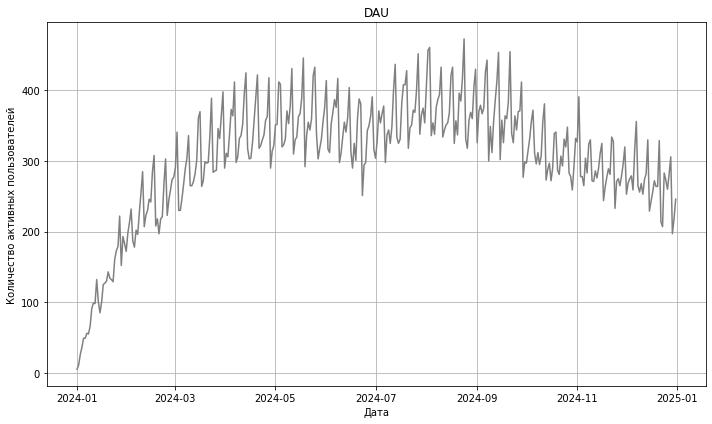

In [18]:
# Рассчитываем DAU и строим визуализацию
# Группируем события по дате и считаем количество уникальных пользователей для каждой из них
dau = events.groupby('event_date')['user_id'].nunique().reset_index()

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(dau['event_date'],dau['user_id'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

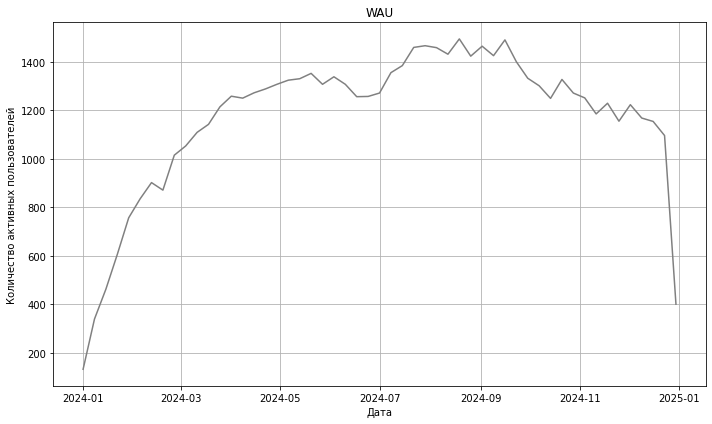

In [19]:
# Рассчитываем WAU и строим визуализацию
# Группируем события по неделе и считаем количество уникальных пользователей для каждой из них
wau = events.groupby('event_week')['user_id'].nunique().reset_index()

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(wau['event_week'],wau['user_id'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('WAU')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

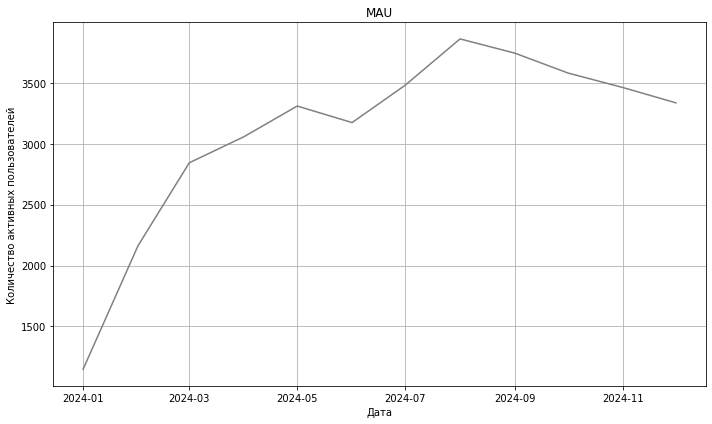

In [20]:
# Рассчитываем MAU и строим визуализацию
# Группируем события по месяцу и считаем количество уникальных пользователей для каждого из них
mau = events.groupby('event_month')['user_id'].nunique().reset_index()

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(mau['event_month'],mau['user_id'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('MAU')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

Показатели DAU, MAU, WAU показывают устойчивый рост с начала 2024 года до августа, а затем наблюдается спад.

---
#### 2.2. Финансовые показатели
Рассчитаем динамику Revenue, количества заказов, AOV, ARPU и ARPPU по месяцам. Метрики сопроводим соответствующей визуализацией. Результаты анализа также зафиксируем в промежуточном выводе.

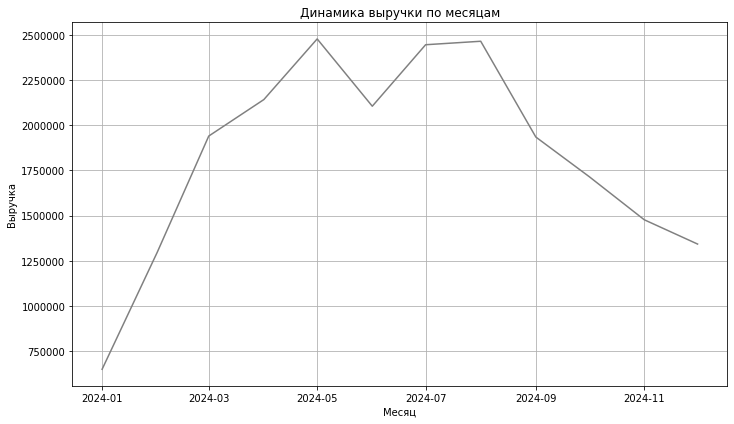

In [21]:
# Считаем выручку (5% от стоимости заказа total_price) и добавляем новый столбец в orders
orders['revenue'] = orders['total_price'] * 0.05

# Группируем данные по месяцу и суммируем выручку
revenue = orders.groupby('order_month')['revenue'].sum().reset_index()

# Строим визуализацию
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(revenue['order_month'],revenue['revenue'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

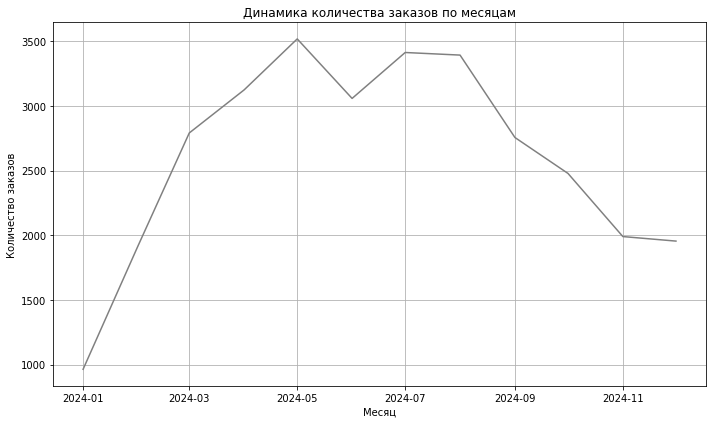

In [22]:
# Группируем данные о заказах по месяцу и считаем количество заказов для каждого месяца
orders_count = orders.groupby('order_month')['order_id'].nunique().reset_index()

# Визуализируем динамику количества заказов по месяцам
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(orders_count['order_month'],orders_count['order_id'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика количества заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

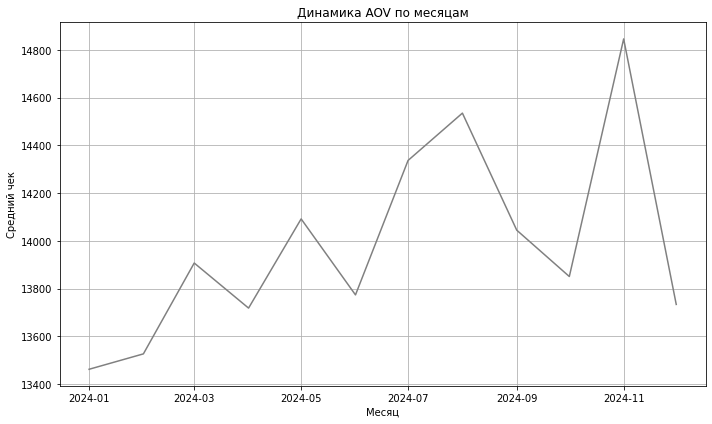

In [23]:
# Рассчитываем AOV и строим визуализацию
# Группируем данные по месяцу и суммируем общую стоимость заказа 
sum_price = orders.groupby('order_month')['total_price'].sum().reset_index()

# Объединяем общую стоимость и общее число заказов
aov_df = pd.merge(sum_price,orders_count,on='order_month',how='inner')

# Считаем AOV
aov_df['aov'] = aov_df['total_price']/aov_df['order_id']

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(aov_df['order_month'],aov_df['aov'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика AOV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

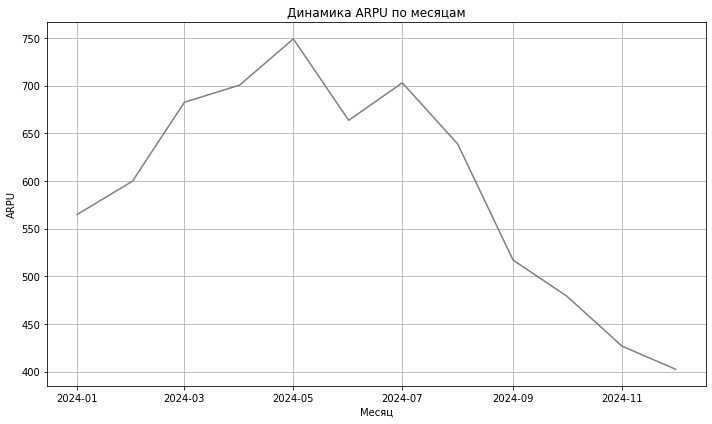

In [24]:
# Рассчитываем ARPU и строим визуализацию
# Группируем данные по месяцу и считаем количество уникальных пользователей
users_count = events.groupby('event_month')['user_id'].nunique().reset_index()

# Объединяем выручку и количество пользователей
arpu_df = pd.merge(revenue[['order_month','revenue']],users_count[['event_month','user_id']],right_on='event_month',left_on='order_month',how='inner')

# Считаем ARPU
arpu_df['arpu'] = arpu_df['revenue']/arpu_df['user_id']

# Визуализируем динамику ARPU по месяцам
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(arpu_df['order_month'],arpu_df['arpu'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика ARPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPU')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

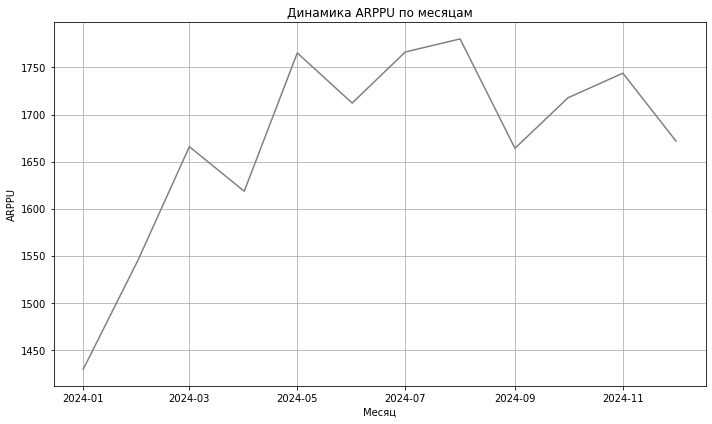

In [25]:
# Рассчитываем ARPPU и строим визуализацию
# Группируем данные по месяцу и считаем количество платящих пользователей
paying_users_count = orders.groupby('order_month')['user_id'].nunique().reset_index()

# Объединяем выручку и количество пользователей
arppu_df = pd.merge(revenue,paying_users_count,on='order_month',how='inner')

# Считаем ARPPU
arppu_df['arppu'] = arppu_df['revenue']/arppu_df['user_id']

# Визуализируем динамику ARPU по месяцам
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(arppu_df['order_month'],arppu_df['arppu'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

Исследуем также динамику конверсии из регистрации в покупку по месяцам. Дополним анализ визуализацией и сделаем промежуточный вывод на основе полученных данных.

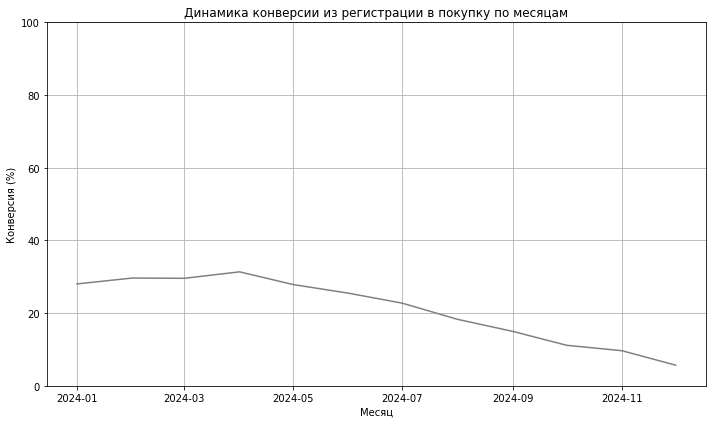

In [26]:
# Рассчитываем и визуализируем динамику конверсии из регистрации в покупку
# Добавляем канал привлечения и месяц когорты в orders (канал привлечения понадобится нам чуть позже, при расчете юнит-экономики)
orders_cohort = pd.merge(orders,users[['user_id','acq_channel','cohort_month']],on='user_id',how='inner')

# Считаем пользователей, которые сделали покупку
buyers = orders_cohort.groupby('cohort_month')['user_id'].nunique().reset_index(name='paying_users')

# Считаем общее число зарегистрированных пользователей
all_users = users.groupby('cohort_month')['user_id'].nunique().reset_index(name='total_users')

# Объединяем общее число зарегистрированных пользователей и количество пользователей, совершивших покупку
cr_df = pd.merge(all_users,buyers,on='cohort_month',how='inner')

# Считаем конверсию по формуле
cr_df['cr_%'] = (cr_df['paying_users']/cr_df['total_users']) * 100

# Визуализируем динамику конверсии по месяцам
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.plot(cr_df['cohort_month'],cr_df['cr_%'],color='gray')

# Добавляем заголовок и подписи осей
plt.title('Динамика конверсии из регистрации в покупку по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Конверсия (%)')

# Добавляем сетку
plt.grid(True)
plt.ylim(0,100)
plt.tight_layout()

# Выводим график
plt.show()

Ухудшения наблюдаются не только в активности пользователей: общая выручка маркетплейса начала падать с августа 2024 года. Одновременно с выручкой, в этот период также начали падать общее количество заказов и ARPU. Средний чек также падал, но был резкий рост в ноябре и затем снова резкое падение метрики в конце года. ARPPU также снизилось, но не так резко и заметно как другие метрики.

В случае с конверсией в покупку, ситуация не лучше: рост наблюдается только в первые 4 месяца и затем показатель плавно идет на снижение. Пик конверсии пришелся на апрель (31.36%) и к декабрю конверсия упала до 5.67%. 

#### Промежуточный вывод
Анализ ключевых метрик показывает, что в первой половине исследуемого периода маркетплейс демонстрировал положительную динамику: росла пользовательская активность (DAU, WAU, MAU), увеличивались выручка и количество заказов. Однако начиная с августа 2024 года практически все ключевые продуктовые и финансовые показатели начали снижаться.

Падение активности пользователей сопровождается сокращением числа заказов, снижением выручки и ARPU, что указывает на ухудшение как вовлеченности аудитории, так и эффективности монетизации. Средний чек в целом также имеет тренд на снижение, несмотря на кратковременный рост в ноябре, а снижение ARPPU свидетельствует о том, что даже платящие пользователи стали приносить меньше выручки.

Дополнительно наблюдается постепенное ухудшение конверсии в покупку: после достижения максимального значения в апреле (31.36%) показатель снизился до 5.67% к концу года. Это может свидетельствовать о возникновении проблем на пути пользователя к покупке или об изменении качества привлекаемой аудитории.

Таким образом, на текущем этапе можно сделать вывод, что после периода роста продукт столкнулся с системным ухудшением ключевых метрик. Для выявления причин необходимо провести более детальный анализ в разрезе каналов привлечения, пользовательских сегментов, категорий товаров и других факторов, которые могут объяснить наблюдаемое снижение.

---
### 3. Оценка метрик монетизации и юнит-экономики

В предыдущем разделе было показано, что начиная с августа наблюдается снижение ключевых метрик. Далее, в разрезе канала привлечения, рассмотрим, насколько эффективно продукт монетизирует пользователей и окупаются ли затраты на их привлечение. 

#### 3.1. Анализ ключевых метрик монетизации 

Для каждого канала привлечения рассчитаем и визуализируем следующие метрики:
* Revenue;
* Orders;
* ARPU;
* ARPPU.

Результаты зафиксируем в кратком промежуточном выводе.

In [27]:
# Чтобы посчитать выручку, количество заказов, ARPU и ARPPU:
# Добавляем канал привлечения из users в orders
orders_acq_df = pd.merge(orders,users[['user_id','acq_channel']],on='user_id',how='left')

# Создаем новый датафрейм из orders с группировкой по каналам привлечения и посчитаем выручку, количество заказов и пользователей
channels_df = orders_acq_df.groupby('acq_channel').agg(
        revenue = ('revenue','sum'),
        orders = ('order_id','nunique'),
        paying_users = ('user_id','nunique')
).reset_index()

# Считаем общее количество привлеченных пользователей из users по каналам
users_acq = users.groupby('acq_channel')['user_id'].nunique().reset_index(name='total_users')

# Присоединяем общее число пользователей по каналам к channels_df
acq_channels_df = pd.merge(channels_df,users_acq,on='acq_channel',how='inner')

In [28]:
# Считаем ARPU по формуле
acq_channels_df['arpu'] = acq_channels_df['revenue'] / acq_channels_df['total_users']

# Считаем ARPPU по формуле
acq_channels_df['arppu'] = acq_channels_df['revenue'] / acq_channels_df['paying_users']

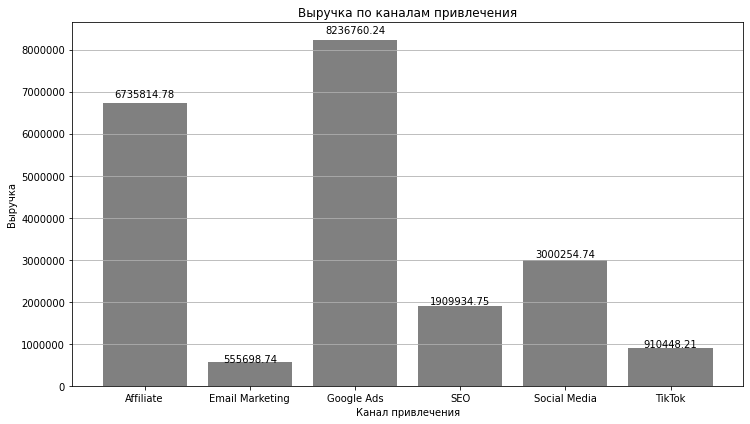

In [29]:
# Визуализируем выручку по каналам привлечения
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(acq_channels_df['acq_channel'],acq_channels_df['revenue'],color='gray')

# Добавляем подписи
for i, value in enumerate(acq_channels_df['revenue']):
    plt.text(i, value * 1.02, f'{value:.2f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Выручка по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Выручка')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

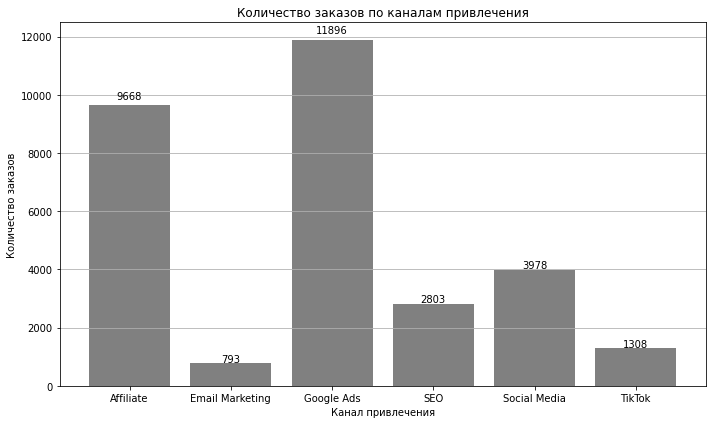

In [30]:
# Визуализируем количество заказов по каналам привлечения
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(acq_channels_df['acq_channel'],acq_channels_df['orders'],color='gray')

# Добавляем подписи
for i, value in enumerate(acq_channels_df['orders']):
    plt.text(i, value * 1.02, f'{value}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Количество заказов по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Количество заказов')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

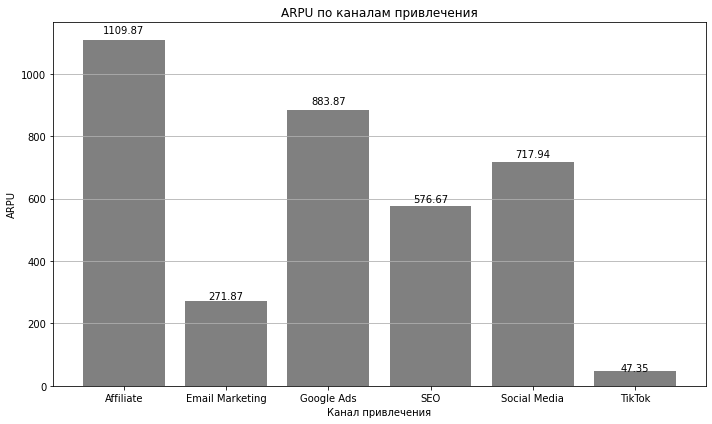

In [31]:
# Визуализируем ARPU по каналам привлечения
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(acq_channels_df['acq_channel'],acq_channels_df['arpu'],color='gray')

# Добавляем подписи
for i, value in enumerate(acq_channels_df['arpu']):
    plt.text(i, value * 1.02, f'{value:.2f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('ARPU по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('ARPU')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

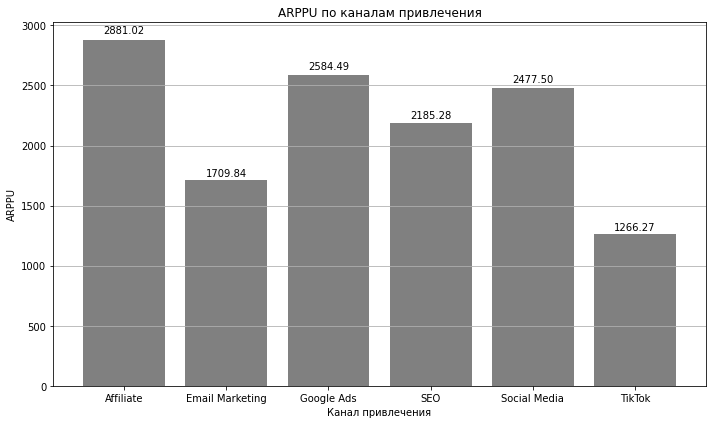

In [32]:
# Визуализируем ARPPU по каналам привлечения
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(acq_channels_df['acq_channel'],acq_channels_df['arppu'],color='gray')

# Добавляем подписи
for i, value in enumerate(acq_channels_df['arppu']):
    plt.text(i, value * 1.02, f'{value:.2f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('ARPPU по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('ARPPU')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

##### Промежуточный вывод
Анализ метрик монетизации показывает существенные различия в эффективности каналов привлечения пользователей.

По общей выручке лидирует Google Ads - 8,24 млн., далее следуют Affiliate (6,74 млн.) и Social Media (3,00 млн.). Эти же каналы формируют наибольшее количество заказов, что свидетельствует об их значительном вкладе в общий объем продаж. Наименее результативными по выручке являются Email Marketing и TikTok.

При оценке ARPU (средняя выручка на одного привлеченного пользователя) наиболее эффективным каналом оказался Affiliate (1110), за ним следуют Google Ads (884) и Social Media (718). Наиболее низкий ARPU наблюдается у TikTok - всего 47. Несмотря на привлечение самого большого количества пользователей (19,2 тыс.), данный канал приносит минимальную выручку в расчете на одного пользователя, что может свидетельствовать о низком качестве привлекаемой аудитории или слабой конверсии в покупку.

По ARPPU (средняя выручка на одного платящего пользователя) лидирует Affiliate (2881), далее идут Google Ads (2584) и Social Media (2478). Это означает, что платящие пользователи, привлеченные через эти каналы, совершают наиболее ценные покупки. Самое низкое значение ARPPU также наблюдается у TikTok (1266), что дополнительно подтверждает его более низкую эффективность.

Таким образом, Affiliate и Google Ads являются наиболее ценными каналами привлечения: они обеспечивают высокую выручку, большое количество заказов и максимальные значения ARPU и ARPPU. В то же время TikTok требует более детального анализа, поскольку привлекает значительный объем пользователей, однако их вклад в выручку и средняя ценность существенно ниже остальных каналов.

Эти результаты следует сопоставить с показателями CAC, ROI и Payback Period, чтобы оценить не только объем получаемой выручки, но и экономическую эффективность каждого канала с учетом затрат на привлечение пользователей.

#### 3.2. Анализ показателей юнит-экономики
Чтобы оценить, окупаются ли каналы привлечения пользователей, проанализируем:
* CAC;
* ROI;
* Payback Period.

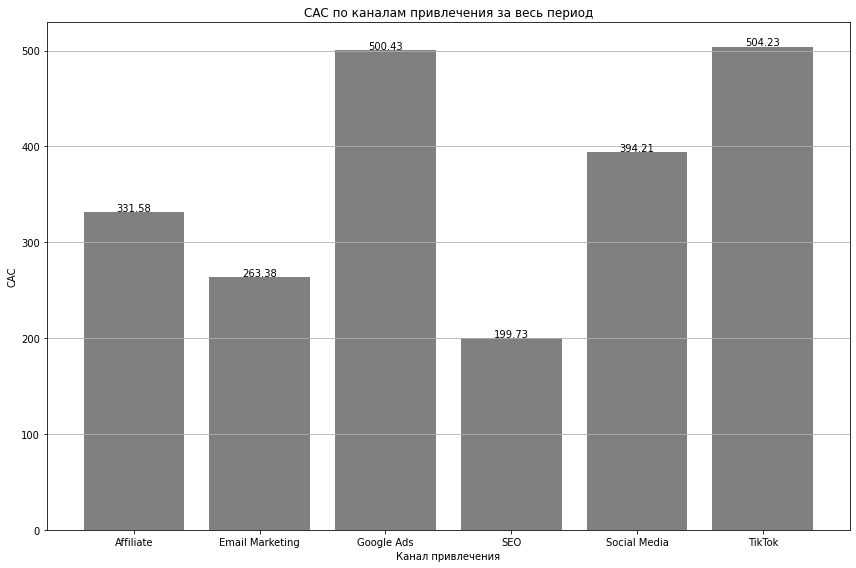

In [33]:
# Рассчитываем САС за весь период по каналам привлечения и строим визуализацию
# Считаем количество привлеченных пользователей для каждого канала
users_acq_total = users.groupby('acq_channel')['user_id'].nunique().reset_index()

# Суммируем затраты по каналам
cac_costs = campaign_costs.groupby('acq_channel')['budget'].sum()

# Объединяем данные о затратах на привлечение и привлеченных пользователях
cac_df_total = pd.merge(cac_costs,users_acq_total,on='acq_channel',how='inner')

# Считаем САС
cac_df_total['cac'] = cac_df_total['budget']/cac_df_total['user_id']

# Задаем размер графика
plt.figure(figsize=(12, 8))

# Строим график
plt.bar(cac_df_total['acq_channel'],cac_df_total['cac'],color='gray')

# Добавляем подписи
for i, value in enumerate(cac_df_total['cac']):
    plt.text(i, value + 1, f'{value:.2f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('CAC по каналам привлечения за весь период')
plt.xlabel('Канал привлечения')
plt.ylabel('CAC')

# Добавляем сетку и легенду
plt.grid(axis='y')
plt.tight_layout()

# Выводим график
plt.show()

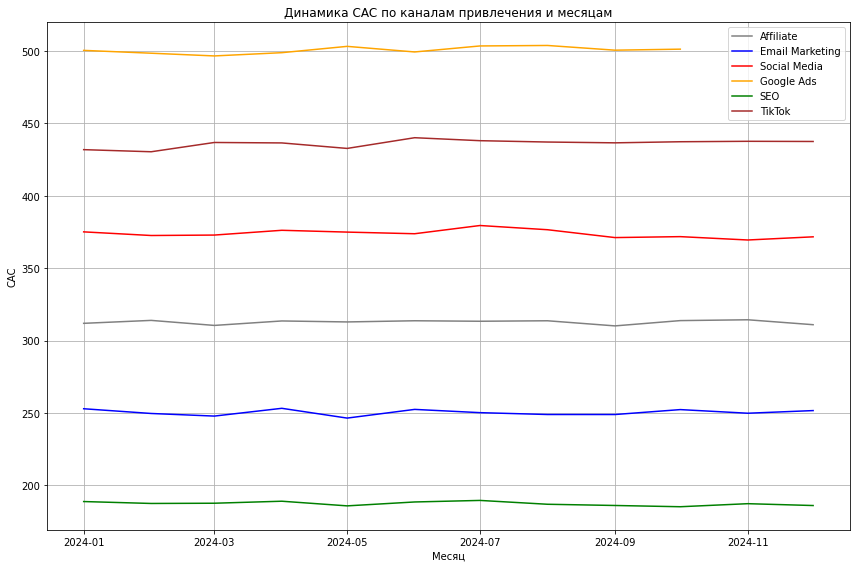

In [34]:
# Рассчитываем САС по месяцам и каналам привлечения и строим визуализацию
# Считаем количество привлеченных пользователей для каждого канала и месяца
users_acq_cac = users.groupby(['cohort_month','acq_channel'])['user_id'].nunique().reset_index()

# Объединяем данные о затратах на привлечение и привлеченных пользователях
cac_df = pd.merge(campaign_costs,users_acq_cac,left_on=['spend_month','acq_channel'],right_on=['cohort_month','acq_channel'],how='inner')

# Считаем САС
cac_df['cac'] = cac_df['budget']/cac_df['user_id']

# Задаем размер графика
plt.figure(figsize=(12, 8))

# Строим график
plt.plot(cac_df[cac_df['acq_channel'] == 'Affiliate']['cohort_month'],cac_df[cac_df['acq_channel'] == 'Affiliate']['cac'],color='gray',label='Affiliate')
plt.plot(cac_df[cac_df['acq_channel'] == 'Email Marketing']['cohort_month'],cac_df[cac_df['acq_channel'] == 'Email Marketing']['cac'],color='blue',label='Email Marketing')
plt.plot(cac_df[cac_df['acq_channel'] == 'Social Media']['cohort_month'],cac_df[cac_df['acq_channel'] == 'Social Media']['cac'],color='red',label='Social Media')
plt.plot(cac_df[cac_df['acq_channel'] == 'Google Ads']['cohort_month'],cac_df[cac_df['acq_channel'] == 'Google Ads']['cac'],color='orange',label='Google Ads')
plt.plot(cac_df[cac_df['acq_channel'] == 'SEO']['cohort_month'],cac_df[cac_df['acq_channel'] == 'SEO']['cac'],color='green',label='SEO')
plt.plot(cac_df[cac_df['acq_channel'] == 'TikTok']['cohort_month'],cac_df[cac_df['acq_channel'] == 'TikTok']['cac'],color='brown',label='TikTok')


# Добавляем заголовок и подписи осей
plt.title('Динамика CAC по каналам привлечения и месяцам')
plt.xlabel('Месяц')
plt.ylabel('CAC')

# Добавляем сетку и легенду
plt.grid(True)
plt.legend()
plt.tight_layout()

# Выводим график
plt.show()

Стоимость привлечения пользователя остается стабильной на протяжении всего исследуемого периода для всех каналов. Значительных колебаний CAC не наблюдается, что свидетельствует о стабильной эффективности маркетинговых кампаний. При этом между каналами существуют существенные различия: наиболее дорогим каналом является Google Ads (≈500 на пользователя), а наименее затратным - SEO (≈187 на пользователя). Для канала Google Ads данные представлены только за 10 месяцев.

In [35]:
# Рассчитываем ROI за весь период и по всем каналам привлечения
# Суммируем выручку из orders_cohort (датафрейм из orders, в который мы добавили cohort_month и acq_channel из users)
roi_revenue = orders_cohort['revenue'].sum()

# Суммируем затраты за весь период
roi_costs = campaign_costs['budget'].sum()

# Считаем ROI по формуле
roi = ((roi_revenue - roi_costs) / roi_costs) * 100

# Выводим результат
print(f'Общий ROI за весь период составил: {roi.round(2)} %')

Общий ROI за весь период составил: 10.46 %


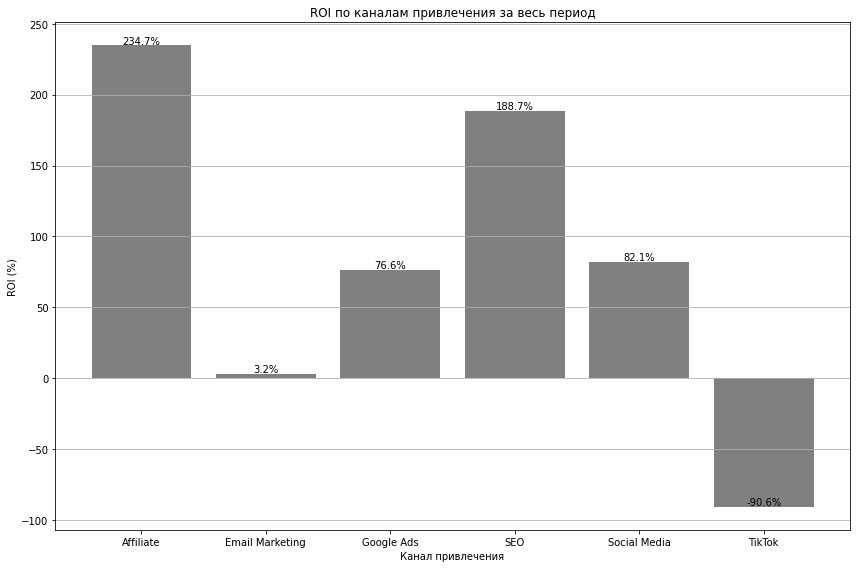

In [36]:
# Рассчитываем ROI за весь период и строим визуализацию
# Суммируем выручку из orders_cohort с группировкой по каналу привлечения
total_revenue = orders_cohort.groupby('acq_channel')['revenue'].sum()

# Суммируем затраты по каналам за весь период
total_costs = campaign_costs.groupby('acq_channel')['budget'].sum().reset_index()

# Объединяем данные о затратах и выручке
roi_df_total = pd.merge(total_revenue,total_costs,on='acq_channel',how='inner')

# Считаем ROI по формуле
roi_df_total['roi_%'] = ((roi_df_total['revenue'] - roi_df_total['budget']) /roi_df_total['budget']) * 100

# Задаем размер графика
plt.figure(figsize=(12, 8))

# Строим график
plt.bar(roi_df_total['acq_channel'],roi_df_total['roi_%'],color='gray')

# Добавляем подписи
for i, value in enumerate(roi_df_total['roi_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

# Добавляем заголовок и подписи осей
plt.title('ROI по каналам привлечения за весь период')
plt.xlabel('Канал привлечения')
plt.ylabel('ROI (%)')

# Добавляем сетку и легенду
plt.grid(axis='y')
plt.tight_layout()

# Выводим график
plt.show()

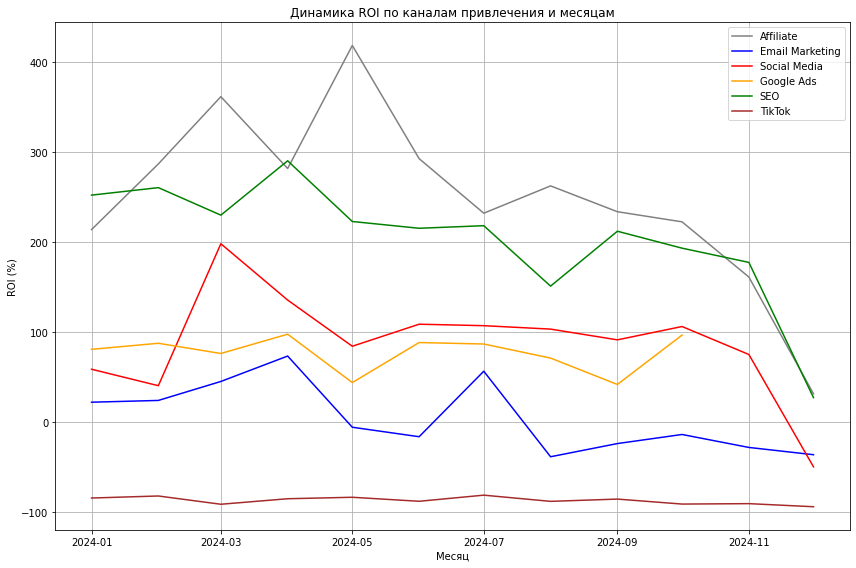

In [37]:
# Рассчитываем ROI по месяцам и каналам привлечения и строим визуализацию
# Суммируем выручку из orders с группировкой по каналу привлечения и месяцу
total_revenue_roi = orders_cohort.groupby(['cohort_month','acq_channel'])['revenue'].sum().reset_index()

# Суммируем затраты по каналам и месяцам
total_costs_roi = campaign_costs.groupby(['spend_month','acq_channel'])['budget'].sum().reset_index()

# Объединяем данные о затратах и выручке
roi_df = pd.merge(total_revenue_roi,total_costs_roi,left_on=['cohort_month','acq_channel'],right_on=['spend_month','acq_channel'],how='inner')

# Считаем ROI по формуле
roi_df['roi_%'] = ((roi_df['revenue'] - roi_df['budget']) /roi_df['budget']) * 100
# Задаем размер графика
plt.figure(figsize=(12, 8))

# Строим график
plt.plot(roi_df[roi_df['acq_channel'] == 'Affiliate']['cohort_month'],roi_df[roi_df['acq_channel'] == 'Affiliate']['roi_%'],color='gray',label='Affiliate')
plt.plot(roi_df[roi_df['acq_channel'] == 'Email Marketing']['cohort_month'],roi_df[roi_df['acq_channel'] == 'Email Marketing']['roi_%'],color='blue',label='Email Marketing')
plt.plot(roi_df[roi_df['acq_channel'] == 'Social Media']['cohort_month'],roi_df[roi_df['acq_channel'] == 'Social Media']['roi_%'],color='red',label='Social Media')
plt.plot(roi_df[roi_df['acq_channel'] == 'Google Ads']['cohort_month'],roi_df[roi_df['acq_channel'] == 'Google Ads']['roi_%'],color='orange',label='Google Ads')
plt.plot(roi_df[roi_df['acq_channel'] == 'SEO']['cohort_month'],roi_df[roi_df['acq_channel'] == 'SEO']['roi_%'],color='green',label='SEO')
plt.plot(roi_df[roi_df['acq_channel'] == 'TikTok']['cohort_month'],roi_df[roi_df['acq_channel'] == 'TikTok']['roi_%'],color='brown',label='TikTok')


# Добавляем заголовок и подписи осей
plt.title('Динамика ROI по каналам привлечения и месяцам')
plt.xlabel('Месяц')
plt.ylabel('ROI (%)')

# Добавляем сетку и легенду
plt.grid(True)
plt.legend()
plt.tight_layout()

# Выводим график
plt.show()

По результатам анализа ROI была оценена эффективность маркетинговых инвестиций за весь период наблюдения, а также проведено сравнение каналов привлечения и динамики показателя во времени. В целом маркетинговая стратегия показала положительную окупаемость с итоговым ROI **10.46%**.

Анализ по каналам привлечения показал, что наиболее эффективными оказались каналы Affiliate, Email Marketing, Google Ads, SEO и Social Media, которые обеспечили положительный ROI на уровне **3.2 - 234.7%** и сформировали наибольшую отдачу от маркетинговых расходов. Данные каналы могут рассматриваться как приоритетные направления для дальнейшего распределения бюджета. В то же время канал TikTok показали отрицательную окупаемость (ROI **-90.6%**), что указывает на необходимость оптимизации рекламных затрат или пересмотра стратегии привлечения пользователей.

Динамика ROI по каналам привлечения показала значительные различия в эффективности маркетинговых расходов. Наиболее стабильные и высокие значения ROI наблюдались у каналов Affiliate и SEO: несмотря на отдельные колебания в течение периода, данные каналы сохраняли положительную окупаемость инвестиций на протяжении большей части анализируемого периода. Однако во второй половине периода наблюдалось постепенное снижение показателя у обоих каналов, что может быть связано с насыщением канала или изменением качества привлечённых пользователей.

Google Ads показывал умеренно положительную эффективность: ROI находился преимущественно в диапазоне около 40–100%, без выраженного долгосрочного роста или снижения. Канал остаётся окупаемым, однако его эффективность ниже, чем у SEO и Affiliate.

Для Social Media характерна высокая изменчивость: в отдельные месяцы канал демонстрировал резкий рост ROI (например, значительное увеличение в марте), после чего показатель постепенно снижался. Это может указывать на зависимость эффективности канала от отдельных маркетинговых активностей, рекламных кампаний или изменений бюджета.

Наименее эффективным каналом оказался TikTok: ROI оставался отрицательным на протяжении всего периода, что означает, что полученная комиссионная выручка не покрывала затраты на привлечение пользователей. Канал требует дополнительной оценки с точки зрения качества аудитории и эффективности расходов.

In [38]:
# Рассчитываем Payback Period
# Уберем строки без заказов
orders_payback = orders_cohort.dropna(subset=['order_month']).copy()

# Считаем месяц жизни пользователя и приводим его к целочисленному типу
orders_payback['N_month'] = ((orders_payback['order_month'].dt.year - orders_payback['cohort_month'].dt.year) * 12 + (orders_payback['order_month'].dt.month - orders_payback['cohort_month'].dt.month))
orders_payback['N_month'] = orders_payback['N_month'].astype(int)

# Считаем выручку каждой когорты по месяцу жизни
cohort_revenue = orders_payback.groupby(['cohort_month','acq_channel','N_month'])['revenue'].sum().reset_index()

# Сортируем данные
cohort_revenue = cohort_revenue.sort_values(['cohort_month','acq_channel','N_month'])

# Считаем накопленную выручку
cohort_revenue['cumulative_revenue'] = cohort_revenue.groupby(['cohort_month','acq_channel'])['revenue'].cumsum()

# Добавляем маркетинговые расходы
payback_df = pd.merge(cohort_revenue,campaign_costs,left_on=['cohort_month','acq_channel'],right_on=['spend_month','acq_channel'],how='left')

# Создаём колонку с месяцем окупаемости
payback_df['payback_month'] = payback_df['cumulative_revenue'] >= payback_df['budget']

# Берём первый месяц окупаемости
payback_result = payback_df[payback_df['payback_month']].groupby(['cohort_month','acq_channel'])['N_month'].min().reset_index(name='payback_period_month')

# Возвращаем обратно все когорты
payback_result = pd.merge(payback_df[['cohort_month','acq_channel']].drop_duplicates(),payback_result,on=['cohort_month','acq_channel'],how='left')

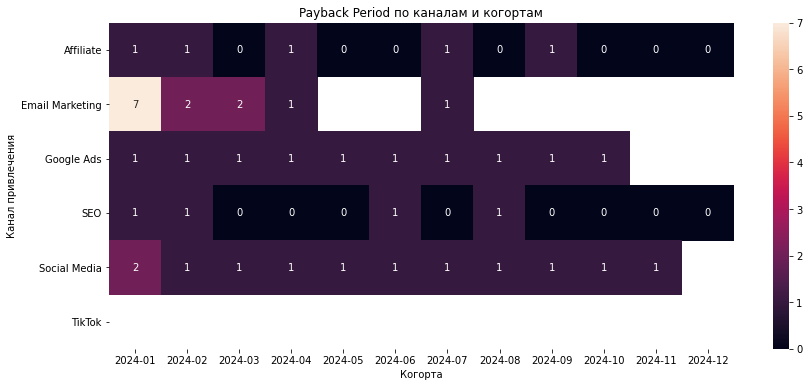

In [39]:
# Визуализируем Payback Period по каналам и когортам
# Создаем сводную таблицу
payback_heatmap = payback_result.pivot(index='acq_channel',columns='cohort_month',values='payback_period_month')

# Задаем формат даты
payback_heatmap.columns = payback_heatmap.columns.strftime('%Y-%m')

# Задаем размер графика
plt.figure(figsize=(14,6))

# Строим heatmap
sns.heatmap(payback_heatmap,annot=True,fmt='.0f')

# Добавляем заголовок и подписи осей
plt.title('Payback Period по каналам и когортам')
plt.xlabel('Когорта')
plt.ylabel('Канал привлечения')

# Показываем график
plt.show()

Анализ Payback Period показал, что большинство каналов способны окупить затраты на привлечение пользователей в течение первых месяцев жизни когорты. Наиболее быстрый возврат инвестиций наблюдается у каналов Google Ads, SEO и Affiliate, где большинство когорт достигают окупаемости уже 0-1 месяц после привлечения. Это говорит о высокой скорости генерации выручки и эффективном использовании маркетингового бюджета.

Канал Social Media также демонстрирует относительно быструю окупаемость: большинство когорт окупаются в течение 1–2 месяцев. При этом отсутствие некоторых значений для отдельных когорт может указывать либо на недостаточный период наблюдения, либо на то, что накопленная выручка ещё не достигла уровня маркетинговых расходов.

Для Email Marketing характерен более длительный период окупаемости. Отдельные когорты требуют до 7 месяцев для возврата инвестиций, что значительно превышает показатели других каналов. Это может свидетельствовать о более длительном цикле принятия решения пользователями или более высокой стоимости привлечения.

Канал TikTok не достигает точки окупаемости в горизонте 12 месяцев: накопленный доход от привлечённых пользователей не покрывает затраты на привлечение.

Некоторые когорты на heatmap имеют пропуски, что означает отсутствие достижения точки окупаемости за доступный период наблюдения. Такие значения не обязательно указывают на неэффективность канала, так как более новые когорты могли иметь недостаточно времени для накопления выручки. Однако при сохранении таких значений в течение длительного периода канал требует дополнительного анализа.

---
##### Промежуточный вывод
Результаты анализа юнит-экономики в целом подтверждают выводы, полученные при оценке ключевых метрик монетизации. Каналы Affiliate и Google Ads, которые ранее показали высокие значения выручки, количества заказов, ARPU и ARPPU, также демонстрируют положительную окупаемость маркетинговых инвестиций и относительно быстрый возврат затрат на привлечение пользователей. SEO, Email Marketing и Social Media также характеризуются положительным ROI, что свидетельствует об эффективности их использования, несмотря на различия в объеме привлекаемой аудитории и скорости окупаемости.

В то же время эффективность каналов различается. SEO и Affiliate демонстрируют наиболее стабильные результаты, тогда как Google Ads и Social Media требуют регулярной оптимизации для сохранения высокой эффективности. Email Marketing окупается медленнее остальных каналов, однако сохраняет положительную экономическую отдачу. Наименее эффективным каналом остается TikTok: несмотря на привлечение большого количества пользователей, он характеризуется низкими значениями ARPU и ARPPU, отрицательной окупаемостью инвестиций и отсутствием возврата затрат даже в течение 12 месяцев. Это указывает на необходимость пересмотра стратегии использования данного канала или оптимизации рекламных кампаний.

## Итоговые выводы по разделам «Обзор ключевых метрик» и «Оценка метрик монетизации и юнит-экономики»

В первой половине исследуемого периода маркетплейс демонстрировал устойчивый рост: увеличивались пользовательская активность, количество заказов и финансовые показатели. Однако начиная с августа 2024 года наблюдается системное снижение ключевых метрик - сокращаются DAU,WAU,MAU, количество заказов, Revenue, ARPU и ARPPU, а также снижается конверсия в заказ. Это указывает на ухудшение как вовлеченности пользователей, так и эффективности монетизации продукта.

Анализ метрик монетизации показал, что наиболее высокий вклад в выручку и количество заказов обеспечивают Google Ads и Affiliate, которые также демонстрируют максимальные значения ARPU и ARPPU. В то же время TikTok, несмотря на привлечение наибольшего количества пользователей, значительно уступает остальным каналам по выручке и ценности привлекаемой аудитории, что свидетельствует о низком качестве трафика.

Результаты анализа юнит-экономики подтверждают эти выводы. Стоимость привлечения пользователей (CAC) остается относительно стабильной, а маркетинговые инвестиции в целом сохраняют положительную окупаемость (ROI - 10,46%). Наиболее эффективными каналами являются Affiliate, SEO, Google Ads, Email Marketing и Social Media, которые обеспечивают положительный возврат инвестиций и могут рассматриваться как основные направления для дальнейшего масштабирования. При этом Google Ads и Social Media требуют регулярной оптимизации для сохранения высокой эффективности, а Email Marketing окупается медленнее других каналов, хотя и сохраняет положительную экономику. TikTok остается наименее эффективным каналом: при текущем уровне затрат он не достигает окупаемости даже в горизонте 12 месяцев, поэтому целесообразно пересмотреть стратегию его использования, оптимизировать рекламные кампании или перераспределить часть бюджета в пользу более эффективных каналов.

Таким образом, текущее снижение ключевых показателей маркетплейса связано не столько с ростом стоимости привлечения пользователей, сколько с ухудшением их качества, снижением активности и эффективности монетизации. Для определения первопричин необходимо провести дополнительный анализ в разрезе каналов привлечения, когорт пользователей, сегментов аудитории и товарных категорий. Это позволит понять, связано ли снижение показателей с изменением качества новых пользователей, сокращением активности существующей аудитории, изменением структуры ассортимента или эффективностью отдельных маркетинговых каналов.

## 4. Поиск инсайтов, точек роста и сегментация


Самое время переходить от общей картины к точечным наблюдениям. Посмотрим вглубь данных: по каналам, сегментам пользователей, категориям товаров, регионам, типам устройств. Будем искать закономерности, различия, аномалии.

Цель - сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов

### 4.1. Построение воронок
В данном подразделе мы построим общие воронки, а также воронки в разрезе операционной системы пользователей, чтобы проанализировать пользовательский путь и определить, сталкиваются ли пользователи с какими-либо проблемами при использовании продукта.

In [40]:
# Задаём порядок шагов в воронке
funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = events[events['event_type'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_type')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

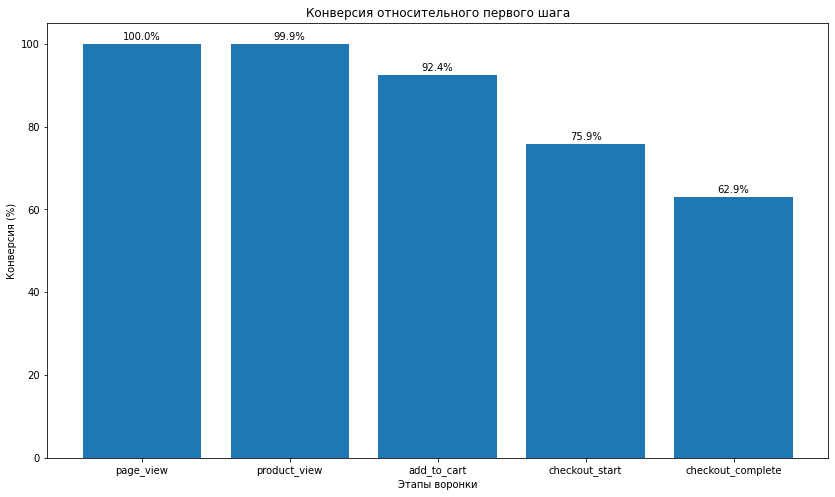

In [41]:
# Строим классическую воронку
# Считаем конверсию относительно первого шага
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)

# Визуализируем данные
plt.figure(figsize=(14, 8))

# Строим barplot
plt.bar(funnel_df['step'],funnel_df['conversion_from_first_%'])

# Добавляем подписи
for i, value in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Конверсия относительного первого шага')
plt.ylabel('Конверсия (%)')
plt.xlabel('Этапы воронки')

# Показываем график
plt.show()

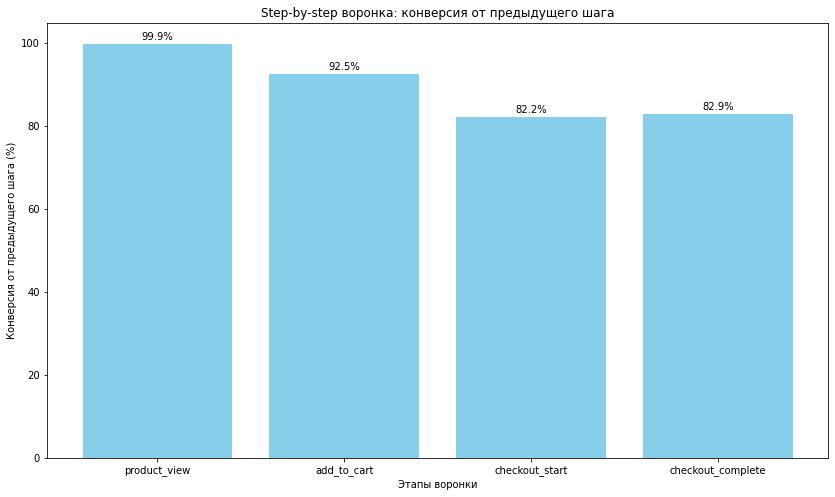

In [42]:
# Строим пошаговую воронку
# Считаем конверсию относительно предыдущего шага
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Строим воронку step-by-step
# Убираем первый шаг, чтобы не выводить NaN
plot_df = funnel_df[funnel_df['step'] != 'page_view']

# Визуализируем данные 
plt.figure(figsize=(14, 8))

# Строим barplot
plt.bar(plot_df['step'], plot_df['conversion_from_previous_%'], color='skyblue')

# Добавляем подписи
for i, value in enumerate(plot_df['conversion_from_previous_%']):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center')
    
# Добавляем заголовок и подписи осей
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')

# Показываем график
plt.show()

Также построим классическую и пошаговую воронки с группировкой по операционной системе пользователя, чтобы понять есть ли проблемы на какой-то из платформ.

In [43]:
# Считаем число уникальных пользователей на каждом шаге с группировкой по ОС
funnel_counts_os = funnel_df_steps.groupby(['os','event_type'])['user_id'].nunique().reset_index()

# Собираем сводную таблицу воронки
funnel_df_os = funnel_counts_os.pivot(index='event_type', columns='os', values='user_id').reindex(funnel_steps)

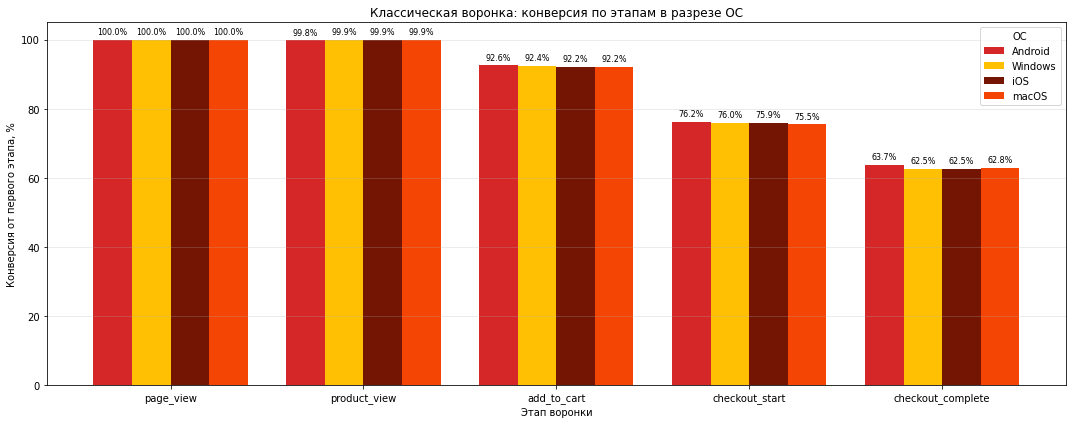

In [44]:
# Строим классическую воронку для каждой ОС
# Считаем конверсию относительно первого шага
conversion_os = (funnel_df_os / funnel_df_os.iloc[0] * 100).round(1)

# Визуализируем данные
plt.figure(figsize=(15, 6))

# Определяем позиции этапов воронки на оси X
x = np.arange(len(conversion_os.index))
width = 0.2

# Создаем список с цветами
colors = ['#d62728', '#ffc003', '#731502', '#f54505']

# Строим столбцы для каждой ОС
for i, os in enumerate(conversion_os.columns):
    bars = plt.bar(x + (i - 1.5) * width, conversion_os[os], width, label=os,color=colors[i])
    
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Настраиваем подписи оси х
plt.xticks(x, conversion_os.index)

# Добавляем заголовок и подписи осей
plt.title('Классическая воронка: конверсия по этапам в разрезе ОС')
plt.xlabel('Этап воронки')
plt.ylabel('Конверсия от первого этапа, %')

# Добавляем сетку и легенду
plt.grid(axis='y', alpha=0.3)
plt.legend(title='ОС')
plt.tight_layout()

# Показываем график
plt.show()

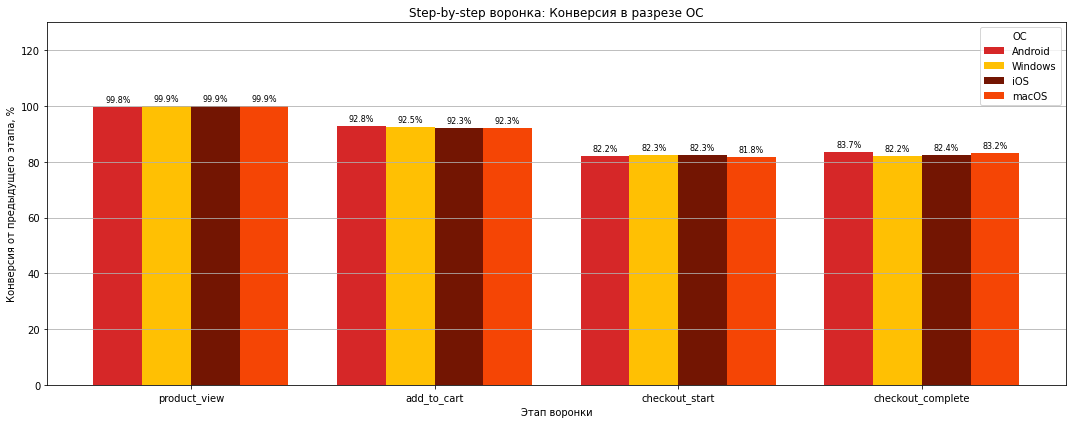

In [45]:
# Строим пошаговую воронку для каждой ОС
# Считаем конверсию относительно предыдущего шага
conversion_os_from_previous = (funnel_df_os / funnel_df_os.shift(1) * 100).round(1)

# Убираем первый шаг, чтобы не выводить NaN
plot_df_os = conversion_os_from_previous[conversion_os_from_previous.index != 'page_view']

# Визуализируем данные
plt.figure(figsize=(15, 6))

# Определяем позиции этапов воронки на оси X
x = np.arange(len(plot_df_os.index))
width = 0.2

# Строим столбцы для каждой ОС
for i, os in enumerate(plot_df_os.columns):
    bars = plt.bar(x + (i - 1.5) * width, plot_df_os[os], width, label=os,color=colors[i])
    # Добавляем подписи 
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom',
            fontsize=8
            )

# Настраиваем подписи оси X
plt.xticks(x, plot_df_os.index)

# Добавляем заголовок и подписи осей
plt.title('Step-by-step воронка: Конверсия в разрезе ОС')
plt.xlabel('Этап воронки')
plt.ylabel('Конверсия от предыдущего этапа, %')

# Добавляем сетку и легенду
plt.grid(axis='y')
plt.legend(title='ОС')
plt.ylim(0,130) # Лимиты по оси у, чтобы легенда не перекрывала столбцы
plt.tight_layout()

# Показываем график
plt.show()

#### Промежуточный вывод
Анализ четырёх воронок показал, что основной отток пользователей происходит на этапе перехода от корзины к оформлению заказа (потеря ~17 п.п. в классической воронке). После начала оформления пользователи с высокой вероятностью завершают покупку - конверсия составляет 82,9%. Различия между ОС минимальны (до 1 п.п.), что говорит об отсутствии выраженного влияния платформы на пользовательское поведение. Основная зона для оптимизации - выявление причин потерь перед началом оформления заказа.

---
### 4.2. География пользователей
Рассчитаем выручку, количество заказов и средний чек для каждого региона. Анализ дополним визуализацией и сделаем промежуточные выводы.

In [46]:
# Считаем количество заказов и выручку с группировкой по региону
# Создаем новый датафрейм с идентификатором пользователя, регионом из users и заказами и выручкой из orders
region_df = pd.merge(users[['user_id','region']],orders[['user_id','order_id','revenue']],on='user_id',how='left')

# Группируем по региону, считаем количество пользователей и заказов, суммируем выручку
region_revenue = region_df.groupby('region').agg(
        orders=('order_id','nunique'),
        revenue=('revenue','sum')
).reset_index()

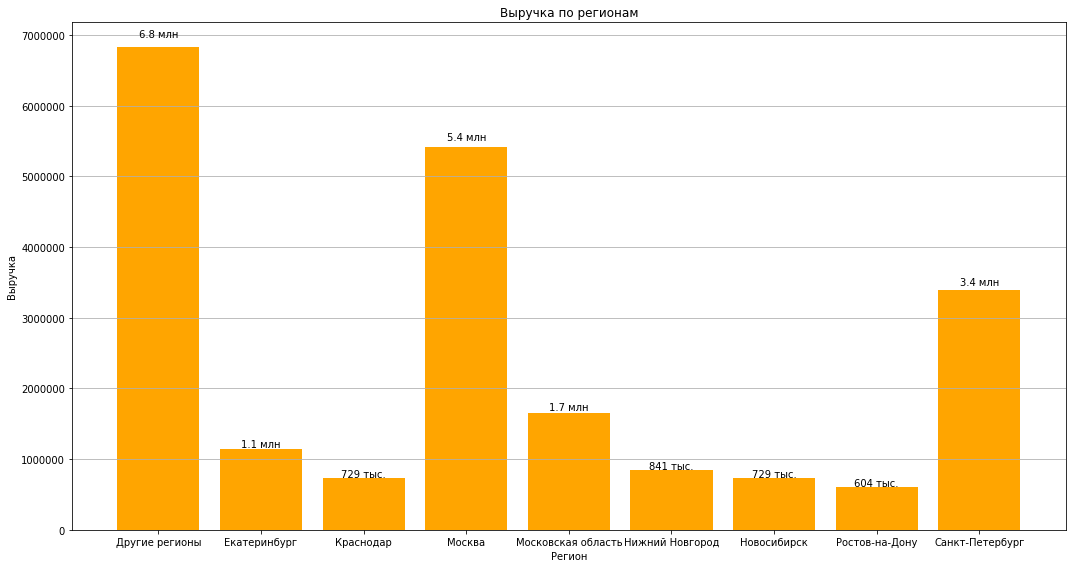

In [47]:
# Визуализируем выручку по регионам
# Задаем размер графика
plt.figure(figsize=(15, 8))

# Строим график
plt.bar(region_revenue['region'],region_revenue['revenue'],color='orange')

# Создаем функцию,которая будет переводить большие числа в тыс. или млн.
def format_revenue(value):
    if value >= 1_000_000:
        return f'{value/1_000_000:.1f} млн'
    elif value >= 1_000:
        return f'{value/1_000:.0f} тыс.'
    else:
        return f'{value:.0f}'

# Добавляем подписи
for i, value in enumerate(region_revenue['revenue']):
    plt.text(i,value * 1.02,format_revenue(value),ha='center')

# Добавляем заголовок и подписи осей
plt.title('Выручка по регионам')
plt.xlabel('Регион')
plt.ylabel('Выручка')

# Добавляем сетку
plt.grid(axis='y')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# Выводим график
plt.show()

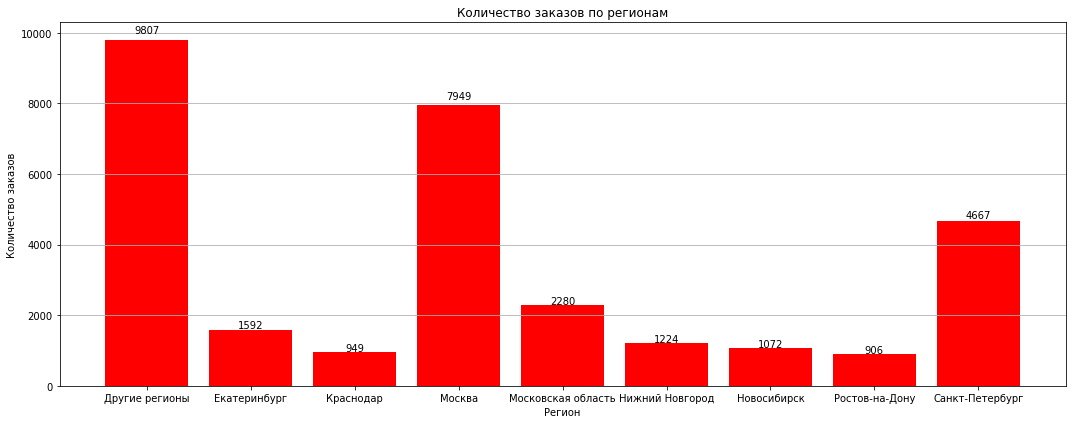

In [48]:
# Визуализируем количество заказов по регионам
# Задаем размер графика
plt.figure(figsize=(15, 6))

# Строим график
plt.bar(region_revenue['region'],region_revenue['orders'],color='red')

# Добавляем подписи
for i, value in enumerate(region_revenue['orders']):
    plt.text(i, value * 1.02, f'{value}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Количество заказов по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество заказов')

# Добавляем сетку
plt.grid(axis='y')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# Выводим график
plt.show()

Дополнительно рассчитаем и визуализируем средний чек (AOV).

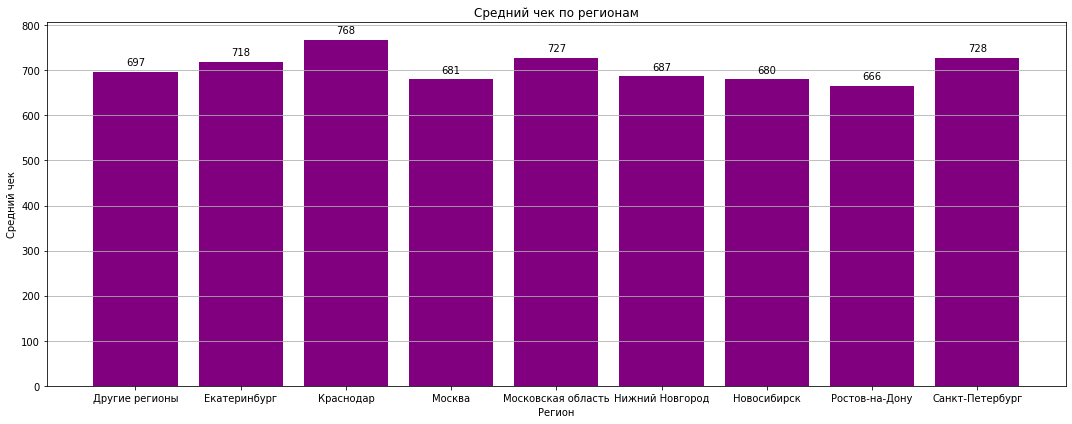

In [49]:
# Считаем AOV по формуле
region_revenue['aov'] = region_revenue['revenue']/region_revenue['orders']

# Строим визуализацию
# Задаем размер графика
plt.figure(figsize=(15, 6))

# Строим столбчатую диаграмму
plt.bar(region_revenue['region'],region_revenue['aov'],color='purple')

# Добавляем подписи
for i, value in enumerate(region_revenue['aov']):
    plt.text(i, value * 1.02, f'{value:.0f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Средний чек по регионам')
plt.xlabel('Регион')
plt.ylabel('Средний чек')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()

# Выводим график
plt.show()

#### Промежуточный вывод
По результатам анализа регионов наибольшую выручку формируют «Другие регионы» (6,8 млн руб.) и Москва (5,4 млн руб.). Эти регионы также лидируют по количеству заказов: 9 807 и 7 949 соответственно, что делает их основными источниками текущей выручки.

По показателю среднего чека наиболее высокий результат демонстрируют Краснодар (768 руб.), Санкт-Петербург (728 руб.) и Московская область (727 руб.), что указывает на более высокую ценность одного заказа в данных регионах. Минимальный средний чек наблюдается в Ростове-на-Дону (666 руб.) и Новосибирске (680 руб.).

Таким образом, регионы-лидеры по объему продаж (Москва и другие регионы) являются приоритетными для масштабирования, так как обеспечивают основной вклад в выручку. При этом регионы с высоким средним чеком (Краснодар, Санкт-Петербург, Московская область) могут быть перспективными для развития дополнительных маркетинговых активностей, направленных на увеличение количества заказов.

---
### 4.3. Анализ в разрезе категорий товаров
На этом этапе проанализируем выручку и количество заказов среди категорий товаров. Расчеты также дополним визуализациями и краткими выводами.

In [50]:
# Считаем количество заказов и выручку с группировкой по категории товара
category_revenue = orders.groupby('category_name').agg(
        orders=('order_id','nunique'),
        revenue=('revenue','sum')
).reset_index()

# Так как категорий много, вместо всех категорий оставим только лидеров
top_categories = (category_revenue.sort_values('revenue', ascending=False).head(10))

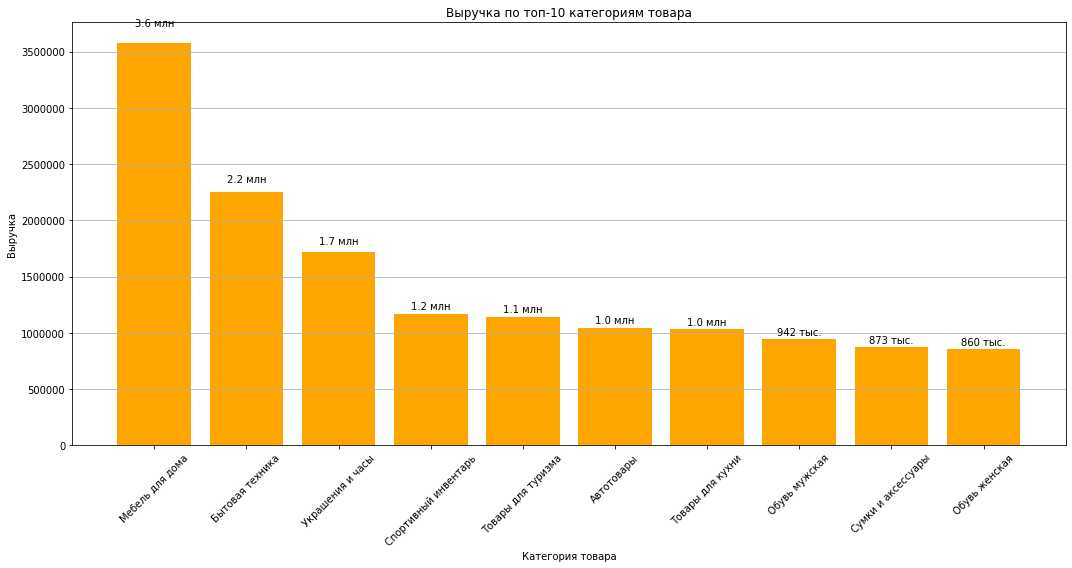

In [51]:
# Визуализируем выручку по категориям товара
# Задаем размер графика
plt.figure(figsize=(15, 8))

# Строим график
plt.bar(top_categories['category_name'],top_categories['revenue'],color='orange')

# Добавляем подписи и применяем созданную ранее функцию format_value
for i, value in enumerate(top_categories['revenue']):
    plt.text(i,value * 1.04,format_revenue(value),ha='center')

# Добавляем заголовок и подписи осей
plt.title('Выручка по топ-10 категориям товара')
plt.xlabel('Категория товара')
plt.ylabel('Выручка')

# Добавляем сетку
plt.grid(axis='y')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()

# Выводим график
plt.show()

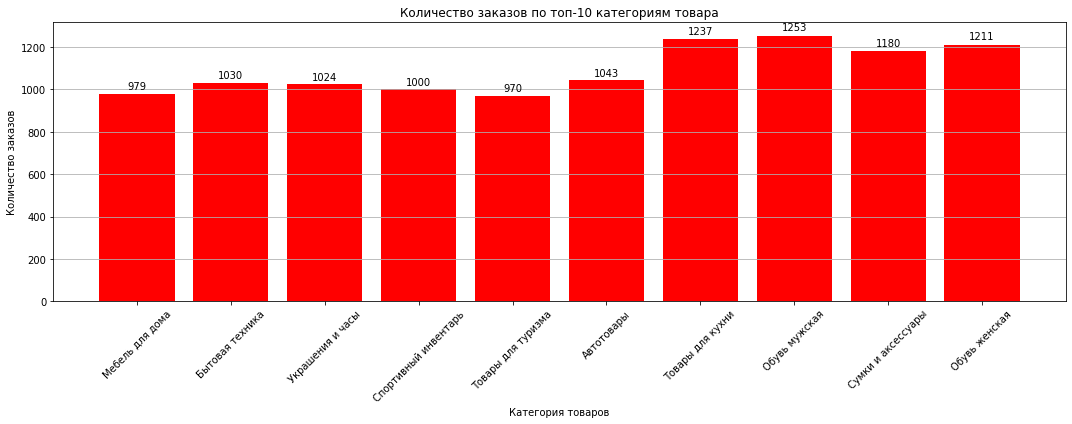

In [52]:
# Визуализируем количество заказов по категориям товара
# Задаем размер графика
plt.figure(figsize=(15, 6))

# Строим график
plt.bar(top_categories['category_name'],top_categories['orders'],color='red')

# Добавляем подписи
for i, value in enumerate(top_categories['orders']):
    plt.text(i, value * 1.02, f'{value}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Количество заказов по топ-10 категориям товара')
plt.xlabel('Категория товаров')
plt.ylabel('Количество заказов')

# Добавляем сетку
plt.grid(axis='y')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()

# Выводим график
plt.show()

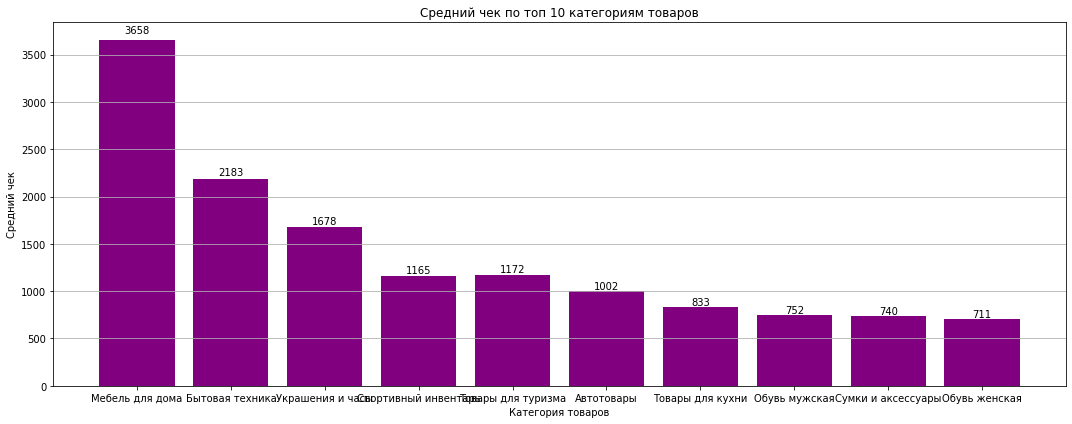

In [53]:
# Считаем AOV по формуле
top_categories['aov'] = top_categories['revenue']/top_categories['orders']

# Строим визуализацию
# Задаем размер графика
plt.figure(figsize=(15, 6))

# Строим столбчатую диаграмму
plt.bar(top_categories['category_name'],top_categories['aov'],color='purple')

# Добавляем подписи
for i, value in enumerate(top_categories['aov']):
    plt.text(i, value * 1.02, f'{value:.0f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Средний чек по топ 10 категориям товаров')
plt.xlabel('Категория товаров')
plt.ylabel('Средний чек')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()

# Выводим график
plt.show()

#### Промежуточный вывод
По результатам анализа категорий товаров по количеству заказов, выручке и среднему чеку выявлено, что наибольший вклад в выручку вносит категория «Мебель для дома» - 3,5 млн руб. При этом категория также демонстрирует самый высокий средний чек среди всех рассмотренных категорий - около 3 652 руб., что указывает на высокую ценность одной покупки.

По количеству заказов лидируют категории «Товары для кухни» (1 208 заказов), «Обувь мужская» (1 195 заказов) и «Обувь женская» (1 182 заказа). Однако их вклад в выручку ниже из-за относительно небольшого среднего чека (около 714–833 руб.). Это говорит о высокой частоте покупок, но меньшей стоимости одного заказа.

Категории «Бытовая техника» и «Украшения и часы» также являются значимыми с точки зрения выручки: они формируют 2,2 млн и 1,7 млн руб. соответственно, при этом имеют высокий средний чек (2 185 руб. и 1 680 руб.).

Таким образом, наиболее перспективными категориями для масштабирования являются «Мебель для дома», «Бытовая техника» и «Украшения и часы», так как они обеспечивают высокий доход за счет высокой стоимости заказа. Категории с большим количеством заказов, но более низким средним чеком («Товары для кухни», «Обувь мужская», «Обувь женская») могут быть интересны для развития стратегий увеличения среднего чека через дополнительные продажи, рекомендации или комплекты товаров.

---
### 4.4. Пользовательские характеристики
В данном разделе проанализируем выручку и ARPU в разрезе возраста и пола пользователя. Построим соответствующие визуализации и подытожим результаты в кратком выводе.

In [54]:
# Создаем функцию, чтобы поделить пользователей на возрастные категории
def age_group(age):
    if 18 <= age <= 34:
        return 'Молодые'
    elif 35 <= age <= 54:
        return 'Взрослые'
    else:
        return 'Пожилые'

# Применяем фнукцию age_group и создаем новый столбец в users с возрастной группой пользователя
users['age_group'] = users['age'].apply(age_group)

# Создаем новый датафрейм с идентификатором пользователя, возрастной группой, полом из users и заказами и выручкой из orders
age_gender_df = pd.merge(users[['user_id','gender','age_group']],orders[['user_id','order_id','revenue']],on='user_id',how='left')

# Считаем количество заказов и пользователей, а также выручку с группировкой по возрасту и полу пользователя
age_gender_revenue = age_gender_df.groupby(['gender','age_group']).agg(
        users=('user_id','nunique'),
        orders=('order_id','nunique'),
        revenue=('revenue','sum')
).reset_index()

# Создаем сводную таблицу для удобного сравнения групп
revenue_pivot = age_gender_revenue.pivot(index='age_group',columns='gender',values='revenue')

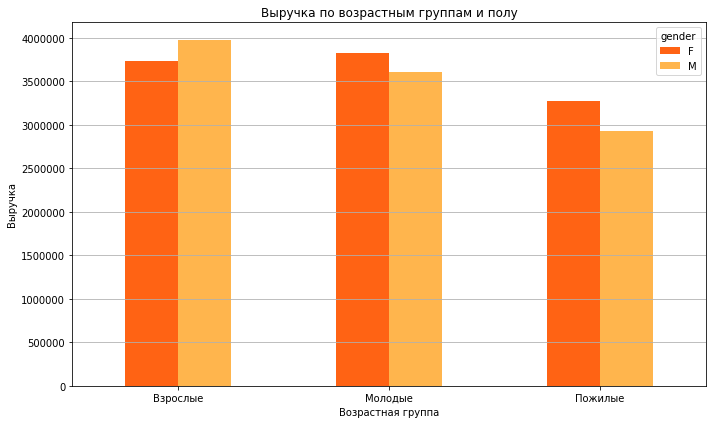

In [55]:
# Визуализируем выручку по полу и возрасту пользователя
revenue_pivot.plot(kind='bar',figsize=(10,6),color=['#ff6314', '#ffb54d'])

# Добавляем заголовок и подписи осей
plt.title('Выручка по возрастным группам и полу')
plt.xlabel('Возрастная группа')
plt.ylabel('Выручка')

# Добавляем сетку
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# Выводим график
plt.show()

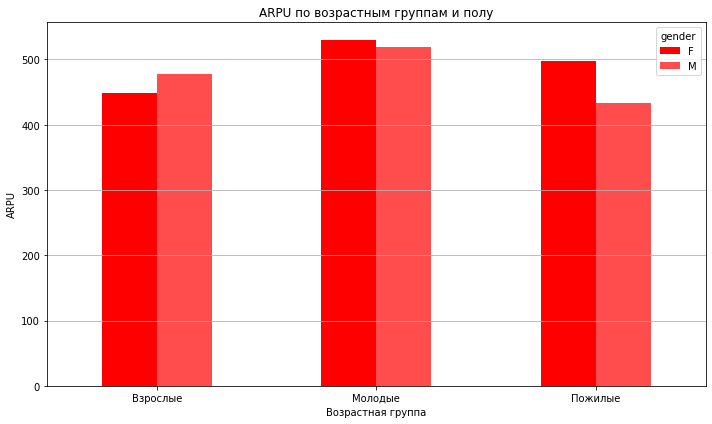

In [56]:
# Считаем ARPU по формуле
age_gender_revenue['arpu'] = age_gender_revenue['revenue']/age_gender_revenue['users']

# Создаем сводную таблицу для удобного сравнения групп
arpu_pivot = age_gender_revenue.pivot(index='age_group',columns='gender',values='arpu')

# Визуализируем ARPU по полу и возрасту пользователя
arpu_pivot.plot(kind='bar',figsize=(10,6),color=['#ff0000', '#ff4d4d'])

# Добавляем заголовок и подписи осей
plt.title('ARPU по возрастным группам и полу')
plt.xlabel('Возрастная группа')
plt.ylabel('ARPU')

# Добавляем сетку
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

# Выводим график
plt.show()

#### Промежуточный вывод
По результатам анализа видно, что наиболее высокий вклад в выручку формируют взрослые пользователи (35-54 года) обоих полов. Среди них лидируют мужчины: выручка составляет 4,0 млн руб., что немного выше показателя женщин того же возраста (3,7 млн руб.). Это указывает на более высокую покупательскую активность мужчин во взрослом сегменте.

Среди молодых пользователей (18-34 года) наблюдается обратная тенденция: женщины формируют большую выручку (3,8 млн руб.), чем мужчины (3,6 млн руб.), а также имеют более высокий показатель ARPU (530 руб. против 520 руб.). Молодая женская аудитория является наиболее ценной группой по выручке на одного пользователя.

Пожилой сегмент (55-70 лет) показывает самые низкие показатели среди всех возрастных групп, особенно среди мужчин: ARPU составляет 434 руб., а выручка - 2,9 млн руб.. Женщины этого возраста демонстрируют более высокий вклад (3,3 млн руб.) и ARPU (498 руб.).

Таким образом, наиболее перспективными сегментами являются:
* мужчины 35-54 лет - за счет максимального количества заказов и наибольшей выручки;
* женщины 18-34 лет - за счет высокого ARPU и потенциала увеличения ценности клиента.

---
### 4.5. Анализ в разрезе канала привлечения
В данном разделе проанализируем количество пользователей, конверсию и средний чек по каналам привлечения пользователей. Построим соответствующие визуализации и результаты оформим в кратком выводе.

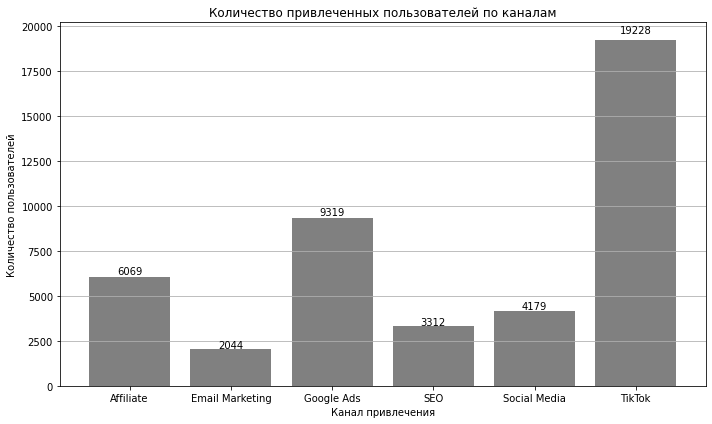

In [57]:
# Считаем количество привлеченных пользователей для каждого канала
users_count_acq = users.groupby('acq_channel')['user_id'].nunique().reset_index()

# Строим столбчатую диаграмму для визуализации
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
plt.bar(users_count_acq['acq_channel'],users_count_acq['user_id'],color='gray')

# Добавляем подписи
for i, value in enumerate(users_count_acq['user_id']):
    plt.text(i, value * 1.02, f'{value}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Количество привлеченных пользователей по каналам')
plt.xlabel('Канал привлечения')
plt.ylabel('Количество пользователей')

# Добавляем сетку
plt.grid(axis='y')
plt.tight_layout()

# Выводим график
plt.show()

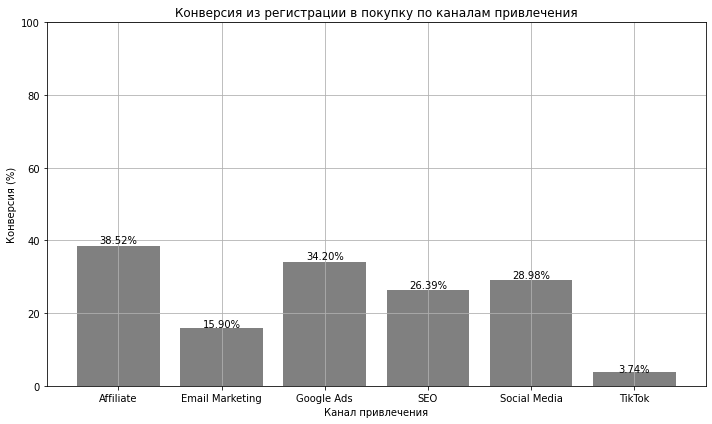

In [58]:
# Считаем пользователей, которые сделали покупку, с группировкой по каналу привлечения
# Воспользуемся созданным ранее датафреймом orders_acq_df, куда мы добавляли канал привлечения
buyers_acq = orders_acq_df.groupby('acq_channel')['user_id'].nunique().reset_index(name='paying_users')

# Считаем общее число зарегистрированных пользователей
all_users_acq = users.groupby('acq_channel')['user_id'].nunique().reset_index(name='total_users')

# Объединяем общее число зарегистрированных пользователей и количество пользователей, совершивших покупку
cr_acq_df = pd.merge(all_users_acq,buyers_acq,on='acq_channel',how='inner')

# Считаем конверсию по формуле
cr_acq_df['cr_%'] = (cr_acq_df['paying_users']/cr_acq_df['total_users']) * 100

# Визуализируем динамику конверсии по месяцам
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(cr_acq_df['acq_channel'],cr_acq_df['cr_%'],color='gray')

# Добавляем подписи
for i, value in enumerate(cr_acq_df['cr_%']):
    plt.text(i, value * 1.02, f'{value:.2f}%', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Конверсия из регистрации в покупку по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Конверсия (%)')

# Добавляем сетку
plt.grid(True)
plt.ylim(0,100)
plt.tight_layout()

# Выводим график
plt.show()

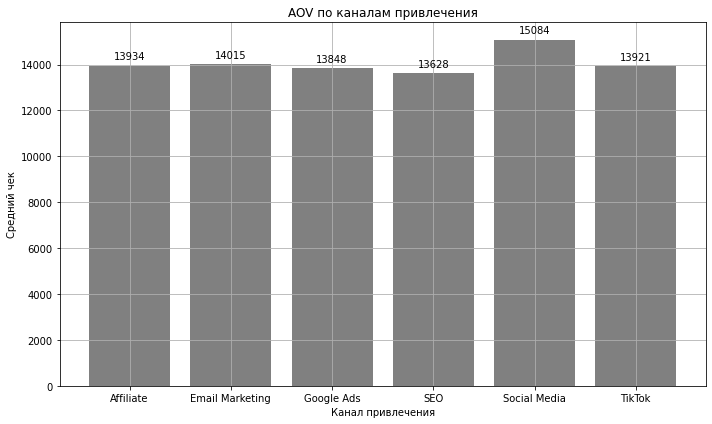

In [59]:
# Рассчитываем средний чек по каналам привлечения и строим визуализацию
# Воспользуемся созданным ранее датафреймами orders_acq_df, куда мы добавляли канал привлечения, и acq_channels_df, где мы считали количество заказов по каналам привлечения
# Группируем данные по каналу привлечения и суммируем общую стоимость заказа 
sum_price_acq = orders_acq_df.groupby('acq_channel')['total_price'].sum().reset_index()

# Объединяем общую стоимость и общее число заказов по каналам привлечения
aov_acq_df = pd.merge(sum_price_acq,acq_channels_df[['acq_channel','orders']],on='acq_channel',how='inner')

# Считаем AOV по формуле
aov_acq_df['aov'] = aov_acq_df['total_price']/aov_acq_df['orders']

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(aov_acq_df['acq_channel'],aov_acq_df['aov'],color='gray')

# Добавляем подписи
for i, value in enumerate(aov_acq_df['aov']):
    plt.text(i, value * 1.02, f'{value:.0f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('AOV по каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Средний чек')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

#### Промежуточный вывод
Анализ каналов привлечения показывает существенные различия в качестве привлекаемой аудитории. По количеству пользователей лидирует TikTok - канал привлек 19,2 тыс. пользователей, что значительно превышает остальные источники. Однако данный канал демонстрирует крайне низкую конверсию в покупку - всего 3,7%, что указывает на низкое качество привлеченного трафика и слабую вовлеченность пользователей после регистрации.

Наиболее высокую конверсию в покупку показывает Affiliate - 38,5%, далее идут Google Ads (34,2%) и Social Media (29,0%). Эти каналы привлекают аудиторию, которая чаще совершает покупки, поэтому могут рассматриваться как наиболее эффективные с точки зрения качества пользователей. SEO показывает средний уровень конверсии (26,4%), а наименьший показатель среди остальных каналов демонстрирует Email Marketing (15,9%).

По показателю среднего чека различия между каналами менее выражены: большинство каналов находятся в диапазоне 13,6-14,0 тыс.. При этом наиболее высокий средний чек наблюдается у Social Media - 15,1 тыс., что говорит о более высокой ценности заказов пользователей из данного канала. Остальные каналы показывают сопоставимый уровень среднего чека, поэтому основное отличие между ними связано не с размером покупки, а с количеством и качеством привлеченных пользователей.

Таким образом, наиболее перспективными каналами с точки зрения качества аудитории являются Affiliate, Google Ads и Social Media: они обеспечивают высокую конверсию в покупку и конкурентный средний чек. TikTok требует дополнительной оптимизации - несмотря на большой объем привлеченной аудитории, низкая конверсия указывает на необходимость пересмотра рекламной стратегии, таргетинга или качества привлекаемого трафика.

---
### 4.5. Поведение пользователей на разных устройствах
В данном подразделе мы будем анализировать количество пользователей, конверсию в покупку и средний чек в зависимости от типа устройства пользователя. 

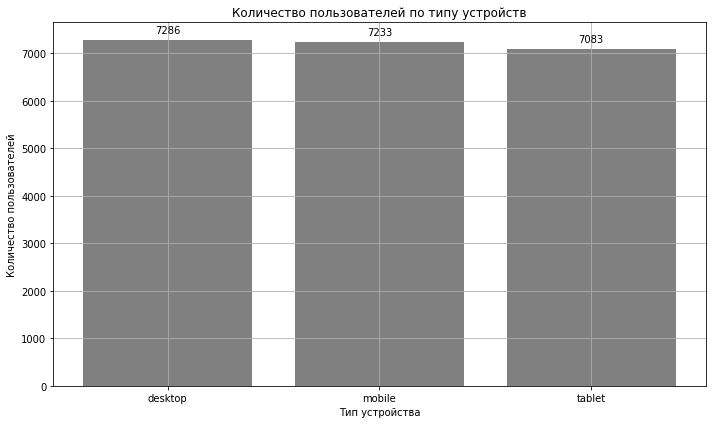

In [60]:
# Считаем количество пользователей в зависимости от типа устройства и строим визуализацию
# Объединяем users и тип устройства из events
device_df = pd.merge(users,events[['user_id','device']],on='user_id',how='left')

# Считаем количество пользователей по каждому типу устройства
total_users_device = device_df.groupby('device')['user_id'].nunique().reset_index(name='total_users')

# Строим столбчатую диаграмму
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(total_users_device['device'],total_users_device['total_users'],color='gray')

# Добавляем подписи
for i, value in enumerate(total_users_device['total_users']):
    plt.text(i, value * 1.02, f'{value}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Количество пользователей по типу устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()

# Выводим график
plt.show()

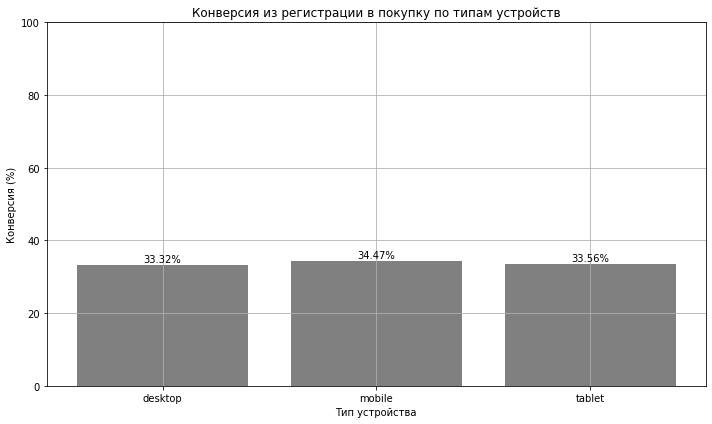

In [61]:
# Считаем конверсию из регистрации в покупку и строим визуализацию
# Оставляем только первое устройство для каждого пользователя, чтобы не было дубликатов
device_users = (events[['user_id', 'device']].drop_duplicates(subset='user_id'))

# Добавляем тип устройства в orders
orders_device = pd.merge(orders[['order_id','user_id','total_price']],device_users,on='user_id',how='left')

# Считаем пользователей, которые сделали покупку, с группировкой по типу устройства
buyers_device = orders_device.groupby('device')['user_id'].nunique().reset_index(name='paying_users')

# Считаем общее число зарегистрированных пользователей
all_users_device = device_df.groupby('device')['user_id'].nunique().reset_index(name='total_users')

# Объединяем общее число зарегистрированных пользователей и количество пользователей, совершивших покупку
cr_device_df = pd.merge(all_users_device,buyers_device,on='device',how='inner')

# Считаем конверсию по формуле
cr_device_df['cr_%'] = (cr_device_df['paying_users']/cr_device_df['total_users']) * 100

# Визуализируем конверсию по типам устройств
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(cr_device_df['device'],cr_device_df['cr_%'],color='gray')

# Добавляем подписи
for i, value in enumerate(cr_device_df['cr_%']):
    plt.text(i, value * 1.02, f'{value:.2f}%', ha='center')

# Добавляем заголовок и подписи осей
plt.title('Конверсия из регистрации в покупку по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Конверсия (%)')

# Добавляем сетку
plt.grid(True)
plt.ylim(0,100)
plt.tight_layout()

# Выводим график
plt.show()

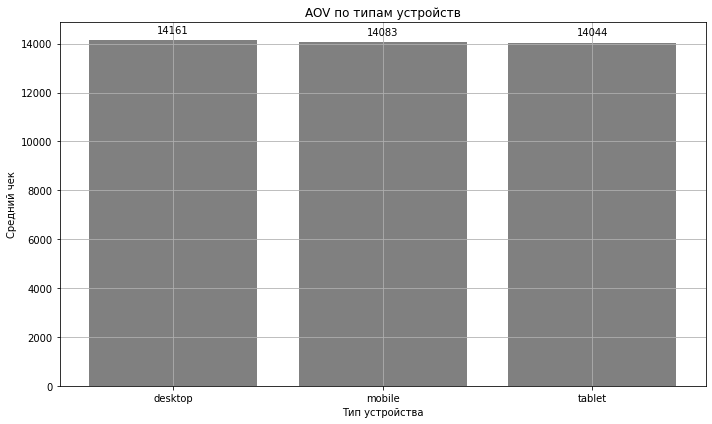

In [62]:
# Рассчитываем средний чек по каналам привлечения и строим визуализацию
# Группируем данные по типу устройства, суммируем общую стоимость заказа и считаем общее число заказов
df_device = orders_device.groupby('device').agg(
    total_price=('total_price','sum'),
    orders=('order_id','nunique')
).reset_index()

# Считаем AOV по формуле
df_device['aov'] = df_device['total_price']/df_device['orders']

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
plt.bar(df_device['device'],df_device['aov'],color='gray')

# Добавляем подписи
for i, value in enumerate(df_device['aov']):
    plt.text(i, value * 1.02, f'{value:.0f}', ha='center')

# Добавляем заголовок и подписи осей
plt.title('AOV по типам устройств')
plt.xlabel('Тип устройства')
plt.ylabel('Средний чек')

# Добавляем сетку
plt.grid(True)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

#### Промежуточный вывод
Анализ пользователей в разрезе типа устройства не выявил существенных различий в ключевых показателях. Количество пользователей, использующих desktop, mobile и tablet, находится на сопоставимом уровне, что свидетельствует о равномерном распределении аудитории между типами устройств.

Конверсия из регистрации в покупку также отличается незначительно: наиболее высокий показатель наблюдается у пользователей мобильных устройств (34,5%), тогда как для desktop и tablet он составляет 33,3% и 33,6% соответственно. Разница менее двух п.п. не позволяет говорить о значимом влиянии типа устройства на вероятность совершения покупки.

Средний чек практически одинаков для всех типов устройств и находится на уровне около 14 тыс.. Незначительно более высокий показатель у пользователей desktop не является существенным с практической точки зрения.

Таким образом, тип устройства не оказывает заметного влияния на покупательское поведение пользователей. На текущем этапе нет оснований для разработки отдельных маркетинговых или продуктовых стратегий для desktop, mobile или tablet. Более перспективным направлением выглядит оптимизация каналов привлечения и работа с качеством привлекаемой аудитории, поскольку именно эти факторы показали значительно более выраженное влияние на конверсию и финансовые показатели.

---
## Выводы по этапу 4

### Выводы
Проведенный анализ пользовательских сегментов, каналов привлечения, категорий товаров, регионов и этапов воронки позволил определить основные факторы, влияющие на качество аудитории и эффективность монетизации.

Анализ пользовательской воронки показал, что основной барьер находится на этапе перехода от добавления товара в корзину к началу оформления заказа. На данном этапе происходит наибольшая потеря пользователей (~17 п.п.), при этом после начала оформления вероятность завершения покупки остается высокой (82,9%). Различия между операционными системами минимальны, что указывает на отсутствие существенного влияния технической платформы на конверсию. 

Анализ регионов показал, что основной вклад в выручку обеспечивают «Другие регионы» (6,8 млн руб.) и Москва (5,4 млн руб.), которые также являются лидерами по количеству заказов. Данные регионы формируют текущую основную базу продаж и являются приоритетными направлениями для дальнейшего масштабирования маркетинговых активностей. При этом Краснодар, Санкт-Петербург и Московская область демонстрируют наиболее высокий средний чек, что говорит о потенциально более ценной аудитории в данных регионах. 

Анализ товарных категорий выявил, что основной драйвер выручки - категория «Мебель для дома», которая формирует максимальный доход (3,5 млн) и имеет самый высокий средний чек среди рассматриваемых категорий (около 3652). Также значимый вклад обеспечивают «Бытовая техника» и «Украшения и часы», которые сочетают высокий объем выручки и высокий средний чек. При этом категории с наибольшим количеством заказов («Товары для кухни», «Обувь мужская», «Обувь женская») характеризуются меньшей стоимостью покупки.

Сегментация пользователей по возрасту и полу показала, что наиболее ценной группой являются взрослые пользователи 35-54 лет. Особенно выделяется мужская аудитория данного возраста: она формирует максимальную выручку (4,0 млн) и имеет наибольшее количество заказов. При этом молодые женщины 18-34 лет демонстрируют наиболее высокий ARPU (530), что указывает на высокий потенциал роста ценности данного сегмента через повышение частоты покупок и удержание пользователей. Пожилой сегмент показывает более низкую экономическую ценность, особенно мужчины 55–70 лет.

Анализ каналов привлечения выявил наиболее существенные различия именно в качестве аудитории. TikTok обеспечивает максимальный объем привлеченного трафика (19,2 тыс. пользователей), однако характеризуется крайне низкой конверсией в покупку (3,7%), что указывает на низкое качество привлеченной аудитории или несоответствие рекламного сообщения ожиданиям пользователей. Наиболее эффективными каналами по качеству аудитории являются Affiliate (38,5% конверсии), Google Ads (34,2%) и Social Media (29,0%), которые обеспечивают высокий уровень перехода зарегистрированных пользователей к покупке. Social Media также демонстрирует наиболее высокий средний чек (15,1 тыс. руб.), что указывает на более высокую ценность привлеченных пользователей.

При этом анализ поведения пользователей в разрезе устройств не выявил значимых различий. Конверсия и средний чек пользователей desktop, mobile и tablet находятся примерно на одном уровне, поэтому выделение отдельных продуктовых стратегий по типам устройств не является приоритетным направлением.

### Практические рекомендации
1. Провести анализ причин отказов пользователей на этапе корзины и оптимизировать этап перехода от корзины к оформлению заказа.
2. Перераспределить маркетинговые ресурсы в пользу эффективных каналов. Рекомендуется увеличить внимание к:
    * Affiliate;
    * Google Ads;
    * Social Media.
3. Оптимизировать затраты или отказать от канала Tik Tok, так как через этот канал приходит некачественная аудитория.
4. Развивать наиболее ценные пользовательские сегменты
    * мужчины 35-54 лет - высокий вклад в выручку и количество заказов;
    * женщины 18-34 лет - высокий ARPU и потенциал роста ценности клиента.
5. Развивать категории с высоким потенциалом выручки ("Мебель для дома", "Бытовая техника", "Украшения и часы").
6. Для категорий с большим количеством заказов и низким средним чеком стимулировать увеличение стоимости корзины через рекомендации сопутствующих товаров и кросс-продажи.

### Гипотезы для развития продукта
**Гипотеза 1:** Упрощение оформления заказа увеличит конверсию в покупку

Основная потеря пользователей происходит между этапами добавления товара в корзину и началом оформления заказа, тогда как после начала оформления конверсия остается высокой (82,9%).

Действия для проверки:
* протестировать сокращение количества шагов оформления;
* добавить более удобные способы оплаты;
* сравнить конверсию контрольной и тестовой групп.

**Гипотеза 2:** Увеличение маркетинговых инвестиций в Affiliate и Google Ads повысит объем продаж

Данные каналы демонстрируют наиболее высокую конверсию в покупку (38,5% и 34,2%) при сопоставимом среднем чеке.

Действия для проверки:
* увеличить бюджет каналов;
* Оценить изменение CAC и ROI после масштабирования.

**Гипотеза 3:** Персонализированные предложения для женщин 18–34 лет увеличат ARPU сегмента

Молодые женщины демонстрируют самый высокий ARPU среди всех сегментов, что указывает на высокий потенциал монетизации.

Действия для проверки:
* внедрить персональные рекомендации;
* протестировать скидки и подборки товаров;
* сравнить изменение частоты покупок и среднего дохода на пользователя.

## 5. Подготовка эксперимента и подведение его результатов

### Новые данные:
```python
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv')
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv')
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv')
```
#### Результаты сплита лежат в таблице:
```python
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')
```
* user_id – id клиента
* group – группа, в которую попал клиент


### Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
#### Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
#### Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
#### Ключевые метрики
##### Основная метрика
- **Конверсия в первую покупку** - доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
##### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
##### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
### Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


### 5.1. Подготовка данных и проверка корректности эксперимента

In [63]:
# Загружаем данные из архива и приводим данные с датами и временем к типу datetime
pa_marketplace_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events_AB.csv',parse_dates=['event_date','event_week','event_month'])
pa_marketplace_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders_AB.csv',parse_dates=['order_date','order_week','order_month'])
pa_marketplace_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users_AB.csv',parse_dates=['registration_date','cohort_week','cohort_month'])
pa_marketplace_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_AB_split_users.csv')

In [64]:
# Проверяем попали ли в тест пользователи из других каналов превлечения
pa_marketplace_users_AB['acq_channel'].unique()

array(['TikTok'], dtype=object)

In [65]:
# Добавим новый столбец с группой пользователя в данные с событиями, заказами и пользователями
# Используем метод объединения inner, чтобы в анализ не попали пользователи без группы
events_AB = pd.merge(pa_marketplace_events_AB,pa_marketplace_AB_split_users,on='user_id',how='inner')
orders_AB = pd.merge(pa_marketplace_orders_AB,pa_marketplace_AB_split_users,on='user_id',how='inner')
users_AB = pd.merge(pa_marketplace_users_AB,pa_marketplace_AB_split_users,on='user_id',how='inner')

In [66]:
# Проверяем период проведения теста
min_date = users_AB['registration_date'].sort_values().min()
max_date = users_AB['registration_date'].sort_values().max()

print(f'Дата начала эксперимента: {min_date}')
print(f'Дата окончания эксперимента: {max_date}')

Дата начала эксперимента: 2025-01-01 00:05:00
Дата окончания эксперимента: 2025-01-26 23:41:00


Согласно дизайн-документу эксперимент должен был проводиться в течение трех недель, однако фактический период регистрации пользователей составил с 1 по 26 января 2025 года (около 26 дней). В дальнейшем анализ проводится по фактически представленным данным.

Стоит отметить, что эксперимент проводился с 1 января - в период новогодних праздников, когда пользовательское поведение может существенно отличаться от обычного. Поскольку распределение пользователей между контрольной и тестовой группами было случайным, это не влияет на корректность сравнения групп, однако может ограничивать переносимость результатов на непраздничные периоды.

In [67]:
# Проверяем, нет ли дублей по user_id
users_AB['user_id'].duplicated().sum()

0

In [68]:
# Проверяем, равномерно ли распределение пользователей по группам
# Посчитаем количество уникальных пользователей в каждой из групп (по датафрейму users_AB)
group_users = users_AB.groupby('group')['user_id'].nunique().reset_index()

# Посмотрим, в каком процентном соотношении они находятся:
group_users['share'] = group_users['user_id'] / group_users['user_id'].sum()

# Выведем результат
group_users

,group,user_id,share
0,control,1503,0.506402
1,treatment,1465,0.493598


Расхождение, кажется, небольшое, и им можно пренебречь. Тем не менее стоит проверить, возможно, дело в пользователях, которые могли попасть в обе группы.

In [69]:
# Проверяем, нет ли пользователей, которые попали в обе группы одновременно
# Создаем переменные, в которых будут хранится пользователи из тестовой и контрольной групп
test = users_AB[users_AB['group'] == 'treatment']['user_id']
control = users_AB[users_AB['group'] == 'control']['user_id']

# Проверяем есть ли пересечения
intersection = list(set(test) & set(control))

# Выводим результат
intersection

[]

Пользователи, которые попали в обе группы, отсутствуют. Проверим распределение пользователей по группам, в зависимости от пола и региона.

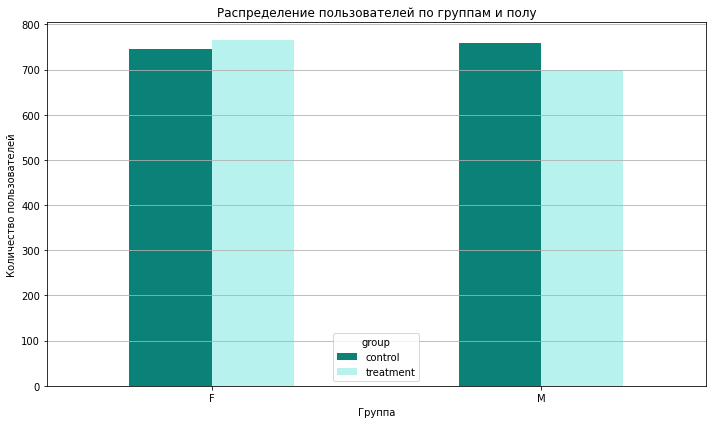

In [70]:
# Проверяем, равномерно ли распределение пользователей по группам в зависимости от пола
# Посчитаем количество уникальных пользователей в каждой из групп (по датафрейму users_AB)
group_gender_users = users_AB.groupby(['group','gender'])['user_id'].nunique().reset_index()

# Создаем сводную таблицу для визуализации
group_gender_pivot = group_gender_users.pivot(index='gender',columns='group',values='user_id')

# Визуализируем результат
# Визуализируем выручку по группе и полу пользователя
group_gender_pivot.plot(kind='bar',figsize=(10,6),color=['#0a8278', '#b8f2ee'])

# Добавляем заголовок и подписи осей
plt.title('Распределение пользователей по группам и полу')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

# Добавляем сетку
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Выводим график
plt.show()

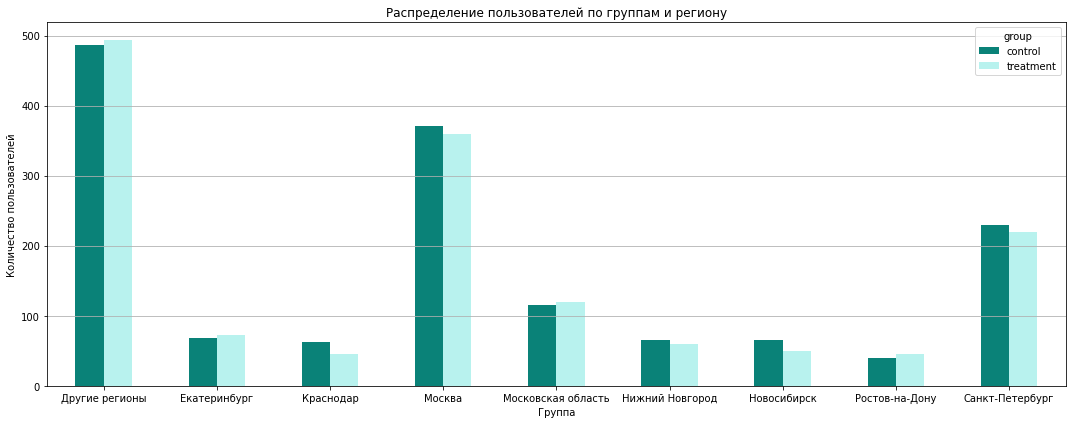

In [71]:
# Проверяем, равномерно ли распределение пользователей по группам в зависимости от региона
# Посчитаем количество уникальных пользователей в каждой из групп (по датафрейму users_AB)
group_region_users = users_AB.groupby(['group','region'])['user_id'].nunique().reset_index()

# Создаем сводную таблицу для визуализации
group_region_pivot = group_region_users.pivot(index='region',columns='group',values='user_id')

# Визуализируем результат
# Визуализируем выручку по группе и полу пользователя
group_region_pivot.plot(kind='bar',figsize=(15,6),color=['#0a8278', '#b8f2ee'])

# Добавляем заголовок и подписи осей
plt.title('Распределение пользователей по группам и региону')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

# Добавляем сетку
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()

# Выводим график
plt.show()

Пользователи распределены между группами практически равномерно: 51% в контрольной группе и 49% в тестовой группе. Распределение пользователей по полу и странам также не имеет выраженных различий. Это позволяет считать рандомизацию корректной и переходить к анализу результатов эксперимента.

### 5.2. Анализ метрик А/В-эксперимента и проверка статистической значимости результатов
В данном подразделе рассчитаем и визуализируем следующие метрики:

**Ключевая метрика:** Конверсия в первую покупку - доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку.

**Вспомогательные метрики:**
* ARPU - средняя выручка на пользователя TikTok;
* ARPPU - средняя выручка на покупателя TikTok;
* AOV - средний чек TikTok.

**Барьерная метрика:** Общая выручка от пользователей TikTok.

Для каждой метрики проверим статистическую значимость результатов и сформулируем промежуточный вывод.

Сформулируем нулевую и альтернативную гипотезы:

**Нулевая гипотеза (H0):** предоставление бонуса на первую покупку пользователям, привлечённым через TikTok, не приводит к изменению конверсии в первую покупку.

**Альтернативная гипотеза (H1):** предоставление бонуса на первую покупку пользователям, привлечённым через TikTok, приводит к увеличению конверсии в первую покупку.

#### 5.2.1. Ключевая метрика

In [72]:
# Рассчитываем конверсию
# Считаем количество зарегистрированных пользователей для каждой группы
registered_users = users_AB.groupby('group')['user_id'].nunique()

# Определим самую раннюю (первую) покупку для каждого пользователя
first_purchase = orders_AB.groupby(['group','user_id'])['order_date'].min().reset_index()

# Считаем количество первых покупок по группам
first_purchase_users = first_purchase.groupby('group')['user_id'].nunique()

# Считаем конверсию из регистрации в первую покупку
groups_cr = (first_purchase_users / registered_users) * 100

# Считаем разницу между тестовой и контрольной группой в абсолютном и относительном значениях
cr_diff_abs = round((groups_cr['treatment'] -  groups_cr['control']),2)
cr_diff_rel = round((groups_cr['treatment'] - groups_cr['control']) / groups_cr['control'] * 100, 2)

# Выведем результат
print('Значение ключевой метрики в контрольной группе:', round((groups_cr['control']),2), '%')
print('Значение ключевой метрики в тестовой группе:', round((groups_cr['treatment']),2), '%')
print('Абсолютная разница:', cr_diff_abs, 'п.п.')
print('Относительная разница:', cr_diff_rel, '%')

Значение ключевой метрики в контрольной группе: 1.06 %
Значение ключевой метрики в тестовой группе: 7.51 %
Абсолютная разница: 6.44 п.п.
Относительная разница: 605.33 %


In [73]:
# Проверяем статистическую значимость через z-тест пропорций
# Определяем количество успехов (покупок)
count = [first_purchase_users['control'],first_purchase_users['treatment']]

# Определяем общее число наблюдений
nobs = [registered_users['control'],registered_users['treatment']]

# Считаем p-value с помощью z-теста пропорций
_, p = proportions_ztest(count, nobs)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Различия статистически значимы, p-value равно 3.164905789805764e-18


##### Промежуточный вывод

В рамках эксперимента была проверена гипотеза о влиянии бонуса на первую покупку на конверсию пользователей TikTok в первую покупку. Контрольная группа показала конверсию 1,06%, тогда как в тестовой группе (с бонусом) конверсия составила 7,51%. Абсолютный прирост конверсии составил **+6,44 п.п.**, относительный прирост - **+605,33%**.

Проверка статистической значимости различий с помощью z-теста для двух пропорций показала, что различия между группами являются статистически значимыми (p-value = 3.164905789805764e-18).

Таким образом, полученные результаты подтверждают гипотезу эксперимента: предоставление бонуса на первую покупку значительно увеличивает вероятность совершения первой покупки пользователями, привлеченными через TikTok.

---
#### 5.2.2. Вспомогательные метрики

##### ARPU

In [74]:
# Считаем ARPU
# Создаем новый столбец с выручкой (5% * total_ptice)
orders_AB['revenue'] = 0.05 * orders_AB['total_price']

# Суммируем выручку по группам
revenue_groups = orders_AB.groupby('group')['revenue'].sum()

# Считаем количество пользователей в users_AB по группам
all_users_groups = users_AB.groupby('group')['user_id'].nunique()

# Считаем ARPU по формуле
arpu_groups = revenue_groups / all_users_groups

# Рассчитаем изменения ключевой метрики в абсолютном и относительном значениях
arpu_diff_abs = round((arpu_groups['treatment'] -  arpu_groups['control']),2)
arpu_diff_rel = round((arpu_groups['treatment'] - arpu_groups['control']) / arpu_groups['control'] * 100, 2)

# Выведем результат
print('Значение вспомогательной метрики №1 (ARPU) в контрольной группе:', round((arpu_groups['control']),2))
print('Значение вспомогательной метрики №1 (ARPU) в тестовой группе:', round((arpu_groups['treatment']),2))
print('Абсолютная разница:', arpu_diff_abs)
print('Относительная разница:', arpu_diff_rel, '%')

Значение вспомогательной метрики №1 (ARPU) в контрольной группе: 12.59
Значение вспомогательной метрики №1 (ARPU) в тестовой группе: 131.25
Абсолютная разница: 118.66
Относительная разница: 942.71 %


In [75]:
# Проверяем статистическую значимость с помощью t-теста Уэлча
# Считаем суммарную выручку каждого пользователя
user_revenue = orders_AB.groupby('user_id')['revenue'].sum().reset_index()

# Добавим выручку в users_AB
users_arpu = pd.merge(users_AB,user_revenue,on='user_id',how='left')

# Заменим пропуски на 0, для пользователей, которые не совершали покупок
users_arpu['revenue'] = users_arpu['revenue'].fillna(0)

# Получим метрику для каждого пользователя (ARPU - выручка на пользователя)
arpu_control = users_arpu[users_arpu['group'] == 'control']['revenue']
arpu_treatment = users_arpu[users_arpu['group'] == 'treatment']['revenue']

# Проводим t-тест Уэлча
_, p = ttest_ind(arpu_control, arpu_treatment, equal_var=False)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Различия статистически значимы, p-value равно 4.093823695234315e-09


###### Промежуточный вывод

По результатам эксперимента ARPU в тестовой группе составил **131.25**, тогда как в контрольной группе - **12,59**. Таким образом, предоставление бонуса на первую покупку привело к увеличению средней выручки на одного пользователя на **118.66**, или на **942.71%** относительно контрольной группы.

При этом различия между группами являются статистически значимыми: p-value составляет 4.093823695234315e-09, что значительно ниже принятого уровня значимости 0,05.

Таким образом, результаты эксперимента свидетельствуют о существенном положительном влиянии бонуса на выручку в расчёте на одного пользователя TikTok. Рост ARPU согласуется с выявленным ранее значительным увеличением конверсии в первую покупку и может указывать на то, что бонус эффективно стимулирует пользователей совершить покупку.

##### ARPPU

In [76]:
# Считаем ARPPU
# Считаем количество платящих пользователей в order_AB по группам
paying_users_groups = orders_AB.groupby('group')['user_id'].nunique()

# Считаем ARPPU по формуле (выручку посчитали в предыдущем блоке)
arppu_groups = revenue_groups / paying_users_groups

# Рассчитаем изменения ключевой метрики в абсолютном и относительном значениях
arppu_diff_abs = round((arppu_groups['treatment'] -  arppu_groups['control']),2)
arppu_diff_rel = round((arppu_groups['treatment'] - arppu_groups['control']) / arppu_groups['control'] * 100, 2)

# Выведем результат
print('Значение вспомогательной метрики №2 (ARPPU) в контрольной группе:', round((arppu_groups['control']),2))
print('Значение вспомогательной метрики №2 (ARPPU) в тестовой группе:', round((arppu_groups['treatment']),2))
print('Абсолютная разница:', arppu_diff_abs)
print('Относительная разница:', arppu_diff_rel, '%')

Значение вспомогательной метрики №2 (ARPPU) в контрольной группе: 1182.42
Значение вспомогательной метрики №2 (ARPPU) в тестовой группе: 1748.0
Абсолютная разница: 565.58
Относительная разница: 47.83 %


In [77]:
# Проверяем статистическую значимость с помощью t-теста Уэлча
# Считаем суммарную выручку для каждого платящего пользователя с группировкой по группе
user_revenue_arppu = orders_AB.groupby(['group', 'user_id'])['revenue'].sum().reset_index()

# Получим метрику для каждого пользователя (ARPPU - выручка на платящего пользователя)
arppu_control = user_revenue_arppu[user_revenue_arppu['group'] == 'control']['revenue']
arppu_treatment = user_revenue_arppu[user_revenue_arppu['group'] == 'treatment']['revenue']

# Проводим t-тест Уэлча
_, p = ttest_ind(arppu_control, arppu_treatment, equal_var=False)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Различия статистически значимы, p-value равно 0.04927676444397778


###### Промежуточный вывод
По результатам эксперимента ARPPU в тестовой группе составил **1 748**, тогда как в контрольной группе  **1 182.42**. Таким образом, средняя выручка на одного платящего пользователя увеличилась на **565.58**, или на **47.83%** относительно контрольной группы.

Статистическая проверка также подтверждает наличие различий между группами: p-value = 0,0493, что немного ниже принятого уровня значимости 0,05. Следовательно, различия в ARPPU можно считать статистически значимыми, хотя эффект находится непосредственно около порога значимости.

Таким образом, бонус на первую покупку не только увеличивает вероятность совершения покупки, но и связан с увеличением средней выручки среди пользователей, которые уже совершили покупку. Это усиливает положительный эффект эксперимента.

##### AOV

In [78]:
# Считаем AOV
# Группируем данные по группам, суммируем общую стоимость заказа и считаем общее число заказов
aov_groups = orders_AB.groupby('group').agg(
    total_price=('total_price', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

# Считаем AOV по формуле
aov_groups['aov'] = aov_groups['total_price'] / aov_groups['orders']

# Рассчитаем изменения метрики в абсолютном и относительном значениях
aov_diff_abs = round(aov_groups.loc[aov_groups['group'] == 'treatment', 'aov'].iloc[0] - aov_groups.loc[aov_groups['group'] == 'control', 'aov'].iloc[0],2)

aov_diff_rel = round((((aov_groups.loc[aov_groups['group'] == 'treatment', 'aov'].iloc[0] - aov_groups.loc[aov_groups['group'] == 'control', 'aov'].iloc[0]) / aov_groups.loc[aov_groups['group'] == 'control', 'aov'].iloc[0]) * 100), 2)

# Выведем результат
print('Значение вспомогательной метрики №3 (AOV) в контрольной группе:', round(aov_groups.loc[aov_groups['group'] == 'control', 'aov'].iloc[0], 2))
print('Значение вспомогательной метрики №3 (AOV) в тестовой группе:', round(aov_groups.loc[aov_groups['group'] == 'treatment', 'aov'].iloc[0], 2))
print('Абсолютная разница:', aov_diff_abs)
print('Относительная разница:', aov_diff_rel, '%')

Значение вспомогательной метрики №3 (AOV) в контрольной группе: 15765.54
Значение вспомогательной метрики №3 (AOV) в тестовой группе: 16647.61
Абсолютная разница: 882.07
Относительная разница: 5.59 %


In [79]:
# Проверяем статистическую значимость с помощью t-теста Уэлча
# Получим метрику для каждого пользователя
aov_control = orders_AB[orders_AB['group'] == 'control']['total_price']
aov_treatment = orders_AB[orders_AB['group'] == 'treatment']['total_price']

# Проводим t-тест Уэлча
_, p = ttest_ind(aov_control, aov_treatment, equal_var=False)

# Задаем уровень значимости
alpha = 0.05

# Интерпретируем результат
if p < alpha:
    print(f'Различия статистически значимы, p-value равно {p}')
else:
    print(f'Статистически значимых различий нет, p-value равно {p}')

Статистически значимых различий нет, p-value равно 0.7872035213045679


###### Промежуточный вывод
По результатам эксперимента средний чек в тестовой группе составил **16 647.61**, тогда как в контрольной группе - **15 765.54**. Таким образом, AOV увеличился на **882.07**, или на **5.59%** относительно контрольной группы.

Однако статистическая проверка не выявила значимых различий между группами: p-value = 0,7872, что значительно превышает уровень значимости 0,05. Следовательно, имеющихся данных недостаточно, чтобы утверждать, что предоставление бонуса на первую покупку действительно влияет на размер среднего чека.

Таким образом, положительная динамика AOV на уровне 5,59% не может рассматриваться как подтверждённый эффект эксперимента. Основное влияние бонуса на финансовые показатели, вероятнее всего, связано не с увеличением стоимости отдельного заказа, а с ростом числа пользователей, совершающих покупку.

---
#### 5.2.3. Барьерная метрика

In [80]:
# Считаем общую выручку по группам
total_revenue_groups = orders_AB.groupby('group')['revenue'].sum()

# Рассчитаем изменения метрики в абсолютном и относительном значениях
revenue_diff_abs = round((total_revenue_groups['treatment'] -  total_revenue_groups['control']),2)
revenue_diff_rel = round((total_revenue_groups['treatment'] - total_revenue_groups['control']) / total_revenue_groups['control'] * 100, 2)

# Выведем результат
print('Значение барьерной метрики (общая выручка) в контрольной группе:', round((total_revenue_groups['control']), 2))
print('Значение барьерной метрики (общая выручка) в тестовой группе:', round((total_revenue_groups['treatment']), 2))
print('Абсолютная разница:', revenue_diff_abs)
print('Относительная разница:', revenue_diff_rel, '%')

Значение барьерной метрики (общая выручка) в контрольной группе: 18918.64
Значение барьерной метрики (общая выручка) в тестовой группе: 192279.85
Абсолютная разница: 173361.21
Относительная разница: 916.35 %


##### Промежуточный вывод
Общая выручка тестовой группы не снизилась и демонстрирует рост относительно контроля. Дополнительно статистически значимый рост ARPU подтверждает положительное влияние эксперимента на выручку в расчёте на одного пользователя.

---
## Выводы по этапу 5

В рамках эксперимента проверялось влияние бонуса на первую покупку на конверсию пользователей, привлечённых через TikTok. В эксперименте приняли участие 2 968 пользователей: 1 503 пользователя вошли в контрольную группу и 1 465 - в тестовую. Распределение между группами было близким к равномерному - 50,6% и 49,4% соответственно. Дубликаты пользователей и случаи попадания одного пользователя одновременно в обе группы отсутствуют. Распределение пользователей по полу и регионам также не выявило существенных дисбалансов между группами, поэтому результаты эксперимента можно считать пригодными для сравнения.

Фактический период эксперимента составил с 1 по 26 января 2025 года, то есть около 26 дней вместо предусмотренных дизайн-документом трёх недель. Кроме того, эксперимент начался в период новогодних праздников. Случайное распределение пользователей позволяет корректно сравнивать контрольную и тестовую группы внутри данного периода, однако сезонность может ограничивать переносимость полученных результатов на обычные периоды.

### Результаты эксперимента

Основная метрика (конверсия из регистрации в первую покупку) продемонстрировала выраженный положительный эффект. Конверсия в контрольной группе составила **1.06%**, а в тестовой - **7.51%**. Абсолютный прирост составил **6.44 п.п.**, относительный - **605.33%**. Различия статистически значимы (p-value = 3.164905789805764e-18). Таким образом, основная гипотеза эксперимента подтверждается: предоставление бонуса на первую покупку существенно увеличивает вероятность совершения первой покупки пользователями TikTok.

Положительный эффект наблюдается и по выручке на пользователя. ARPU вырос с **12.59** до **131.25**, то есть на **118.66** или **942.71%**. Различия статистически значимы (p-value = 4.093823695234315e-09). Это согласуется с результатами по конверсии и показывает, что увеличение числа покупателей сопровождается существенным ростом выручки в расчёте на пользователя.

ARPPU также увеличился: с **1 182.42** до **1 748**, или на **47.83%**. Различия статистически значимы при принятом уровне значимости 5% (p-value = 0,0493). Однако результат находится непосредственно около порогового значения, поэтому его следует интерпретировать осторожно и желательно дополнительно проверить на последующих данных.

При этом статистически значимого изменения AOV обнаружено не было. Средний чек увеличился с **15 765.54** до **16 647.61**, или на **5.59%**, однако p-value = 0,7872. Следовательно, нельзя утверждать, что бонус влияет на размер отдельного заказа.

Совокупность результатов позволяет предположить, что основной механизм воздействия бонуса связан не с увеличением стоимости заказа, а прежде всего с переводом большего количества зарегистрированных пользователей в покупателей. Иными словами, бонус эффективно снижает барьер для совершения первой покупки, но не приводит к статистически подтверждённому увеличению среднего чека.

Общая выручка тестовой группы также не продемонстрировала снижения относительно контрольной группы. В совокупности с статистически значимым ростом ARPU это свидетельствует в пользу положительного финансового эффекта эксперимента. Однако окончательно оценивать экономическую эффективность механики только по выручке нельзя, поскольку при принятии решения необходимо учитывать стоимость предоставленных бонусов.

Результаты эксперимента в целом подтверждают эффективность бонуса на первую покупку для пользователей TikTok. Основная метрика продемонстрировала статистически значимый рост, а положительная динамика ARPU и ARPPU указывает на потенциальный финансовый эффект механики.

Бонус можно рассматривать для дальнейшего масштабирования на аудиторию TikTok, однако перед полномасштабным запуском рекомендуется дополнительно оценить его экономическую эффективность - сопоставить прирост выручки со стоимостью бонусов и определить влияние механики на прибыль.

### Ограничения и проблемы эксперимента
* Фактическая длительность эксперимента отличалась от дизайн-документа. Вместо трёх недель пользователи регистрировались около 26 дней. Это необходимо учитывать при интерпретации результатов и планировании следующих экспериментов.
* Эксперимент начался 1 января, в период новогодних праздников. Поведение пользователей в этот период может отличаться от стандартного. Поэтому результаты желательно подтвердить на данных после окончания праздничного периода.
* Размер выборки и мощность эксперимента заранее не рассчитывались. Эксперимент был запущен без предварительного определения MDE и необходимого размера выборки из-за срочности задачи. 
* ARPPU находится около границы статистической значимости. Значение p-value = 0,0493 лишь немного ниже 0,05, поэтому данный результат менее устойчив, чем эффект по CR и ARPU.
* Не учитывается стоимость бонуса при оценке финансового эффекта. Рост выручки не обязательно означает рост прибыли. Для принятия окончательного бизнес-решения необходимо оценить чистый финансовый эффект после вычета стоимости бонусов.

### Рекомендации
1. Провести экономическую оценку бонуса.
Рассчитать прирост дополнительной выручки и сопоставить его со стоимостью предоставленных бонусов. Основной показатель для принятия решения о масштабировании - не только рост CR и ARPU, но и положительный прирост прибыли.

2. Рассмотреть масштабирование бонуса на пользователей TikTok.
Так как бонус значительно повысил конверсию пользователей TikTok в первую покупку, стоит рассмотреть возможность продолжить использовать эту механику для данного канала.

3. Подтвердить эффект в обычный период.
Рекомендуется повторно проверить ключевые результаты после новогоднего периода или провести дополнительный тест, чтобы убедиться, что эффект не связан преимущественно с сезонным поведением пользователей.

4. Не делать ставку на увеличение среднего чека.
AOV не показал статистически значимого роста, поэтому бонус следует рассматривать прежде всего как инструмент увеличения конверсии в первую покупку, а не как инструмент увеличения суммы отдельного заказа.